In [1]:
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.8 MB/s eta 0:00:00


In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

from pathlib import Path
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
from pathlib import Path

# Search Kaggle's input directory for anything related to SOS / oil spill
for p in Path("/kaggle/input").iterdir():
    print(p)

In [4]:
from pathlib import Path

DATA_DIR = Path("/kaggle/working/sos_dataset")
DATA_DIR.mkdir(parents=True, exist_ok=True)

%cd /kaggle/working/sos_dataset

# Download
!wget -q --show-progress \
    "https://zenodo.org/records/15298010/files/Refined_SOS.zip?download=1" \
    -O Refined_SOS.zip

# Extract
!unzip -q Refined_SOS.zip -d extracted

# Verify extraction before deleting the ZIP
!find extracted -type f | head -20

# Delete the ZIP to recover disk space
!rm -f Refined_SOS.zip

# Check remaining storage
!du -sh /kaggle/working/sos_dataset
!df -h /kaggle/working

/kaggle/working/sos_dataset
[Refined_SOS.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of Refined_SOS.zip or
        Refined_SOS.zip.zip, and cannot find Refined_SOS.zip.ZIP, period.
find: ‘extracted’: No such file or directory
4.0K	/kaggle/working/sos_dataset
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  504K   20G   1% /kaggle/working


In [5]:
import requests

url = "https://zenodo.org/api/records/15298010"
data = requests.get(url).json()

for f in data["files"]:
    print(f["key"], f["links"]["self"])

images.zip https://zenodo.org/api/records/15298010/files/images.zip/content
masks.zip https://zenodo.org/api/records/15298010/files/masks.zip/content


In [6]:
from pathlib import Path

DATA_DIR = Path("/kaggle/working/sos_dataset")
DATA_DIR.mkdir(parents=True, exist_ok=True)

%cd /kaggle/working/sos_dataset

!wget -q --show-progress \
    "https://zenodo.org/api/records/15298010/files/images.zip/content" \
    -O images.zip

/kaggle/working/sos_dataset
images.zip          100%[===================>]   1.07G  11.7MB/s    in 4m 55s  


In [7]:
!ls -lh images.zip
!df -h /kaggle/working

-rw-r--r-- 1 root root 1.1G Aug 26 18:06 images.zip
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  1.1G   19G   6% /kaggle/working


In [8]:
!unzip -q images.zip -d images

In [9]:
!find images -type f | head -10

images/__MACOSX/images/._val
images/__MACOSX/images/val/._palsar_195.png
images/__MACOSX/images/val/._palsar_434.png
images/__MACOSX/images/val/._sentinel_293.png
images/__MACOSX/images/val/._sentinel_596.png
images/__MACOSX/images/val/._sentinel_101.png
images/__MACOSX/images/val/._sentinel_186.png
images/__MACOSX/images/val/._sentinel_502.png
images/__MACOSX/images/val/._palsar_420.png
images/__MACOSX/images/val/._sentinel_284.png
find: ‘standard output’: Broken pipe
find: write error


In [10]:
!find images/images -type f | head -20

images/images/val/sentinel_179.png
images/images/val/palsar_93.png
images/images/val/sentinel_589.png
images/images/val/sentinel_726.png
images/images/val/palsar_137.png
images/images/val/palsar_162.png
images/images/val/sentinel_166.png
images/images/val/palsar_190.png
images/images/val/sentinel_129.png
images/images/val/palsar_172.png
images/images/val/palsar_20.png
images/images/val/sentinel_265.png
images/images/val/palsar_652.png
images/images/val/sentinel_356.png
images/images/val/palsar_544.png
images/images/val/sentinel_732.png
images/images/val/palsar_556.png
images/images/val/palsar_146.png
images/images/val/sentinel_96.png
images/images/val/sentinel_832.png
find: ‘standard output’: Broken pipe
find: write error


In [11]:
!rm -f /kaggle/working/sos_dataset/images.zip

In [12]:
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  1.3G   19G   7% /kaggle/working


In [13]:
from pathlib import Path

DATA_DIR = Path("/kaggle/working/sos_dataset")
%cd /kaggle/working/sos_dataset

!wget -q --show-progress \
    "https://zenodo.org/api/records/15298010/files/masks.zip/content" \
    -O masks.zip

/kaggle/working/sos_dataset
masks.zip           100%[===================>]  26.97M  3.53MB/s    in 9.5s    


In [14]:
!ls -lh masks.zip
!df -h /kaggle/working

-rw-r--r-- 1 root root 27M Aug 26 18:06 masks.zip
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  1.4G   19G   7% /kaggle/working


In [15]:
!unzip -q masks.zip -d masks

In [16]:
!find masks/masks -type f | head -20

masks/masks/val/sentinel_179.png
masks/masks/val/palsar_93.png
masks/masks/val/sentinel_589.png
masks/masks/val/sentinel_726.png
masks/masks/val/palsar_137.png
masks/masks/val/palsar_162.png
masks/masks/val/sentinel_166.png
masks/masks/val/palsar_190.png
masks/masks/val/sentinel_129.png
masks/masks/val/palsar_172.png
masks/masks/val/palsar_20.png
masks/masks/val/sentinel_265.png
masks/masks/val/palsar_652.png
masks/masks/val/sentinel_356.png
masks/masks/val/palsar_544.png
masks/masks/val/sentinel_732.png
masks/masks/val/palsar_556.png
masks/masks/val/palsar_146.png
masks/masks/val/sentinel_96.png
masks/masks/val/sentinel_832.png
find: ‘standard output’: Broken pipe
find: write error


In [17]:
!rm -f /kaggle/working/sos_dataset/masks.zip

In [18]:
from pathlib import Path

IMAGE_DIR = Path("/kaggle/working/sos_dataset/images/images/train")
MASK_DIR  = Path("/kaggle/working/sos_dataset/masks/masks/train")

images = sorted(IMAGE_DIR.glob("*.png"))
masks  = sorted(MASK_DIR.glob("*.png"))

print("Images:", len(images))
print("Masks :", len(masks))

image_names = {p.name for p in images}
mask_names  = {p.name for p in masks}

print("Images without masks:", len(image_names - mask_names))
print("Masks without images:", len(mask_names - image_names))

print("\nExample:")
print("Image:", images[0])
print("Mask :", MASK_DIR / images[0].name)

Images: 6455
Masks : 6455
Images without masks: 0
Masks without images: 0

Example:
Image: /kaggle/working/sos_dataset/images/images/train/palsar_0.png
Mask : /kaggle/working/sos_dataset/masks/masks/train/palsar_0.png


In [19]:
from PIL import Image
import numpy as np

img_path = images[0]
mask_path = MASK_DIR / img_path.name

img = Image.open(img_path)
mask = Image.open(mask_path)

img_array = np.array(img)
mask_array = np.array(mask)

print("Image:")
print("  Size   :", img.size)
print("  Mode   :", img.mode)
print("  Shape  :", img_array.shape)
print("  Dtype  :", img_array.dtype)

print("\nMask:")
print("  Size   :", mask.size)
print("  Mode   :", mask.mode)
print("  Shape  :", mask_array.shape)
print("  Dtype  :", mask_array.dtype)
print("  Values :", np.unique(mask_array)[:20])

Image:
  Size   : (256, 256)
  Mode   : RGB
  Shape  : (256, 256, 3)
  Dtype  : uint8

Mask:
  Size   : (256, 256)
  Mode   : RGB
  Shape  : (256, 256, 3)
  Dtype  : uint8
  Values : [  0 255]


In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np


class OilSpillDataset(Dataset):

    def __init__(self, image_paths, mask_dir):
        self.image_paths = image_paths
        self.mask_dir = Path(mask_dir)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        # ---------- Image ----------
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")

        image = np.array(image).astype(np.float32)

        # RGB → grayscale
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Same normalization used by your previous model
        image = image / 255.0
        image = (image - 0.5) / 0.5

        # H,W → 1,H,W
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)

        # ---------- Mask ----------
        mask_path = self.mask_dir / image_path.name
        mask = Image.open(mask_path).convert("L")

        mask = np.array(mask).astype(np.float32)

        # 0/255 → 0/1
        mask = (mask > 127).astype(np.float32)

        # H,W → 1,H,W
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [21]:
train_dataset = OilSpillDataset(
    images,
    MASK_DIR
)

print("Dataset size:", len(train_dataset))

Dataset size: 6455


In [22]:
image_tensor, mask_tensor = train_dataset[0]

print("Image shape:", image_tensor.shape)
print("Mask shape :", mask_tensor.shape)

print("Image range:",
      image_tensor.min().item(),
      image_tensor.max().item())

print("Mask values:",
      torch.unique(mask_tensor))

Image shape: torch.Size([1, 256, 256])
Mask shape : torch.Size([1, 256, 256])
Image range: -1.0 1.0
Mask values: tensor([0., 1.])


In [23]:
from sklearn.model_selection import train_test_split

train_images, val_images = train_test_split(
    images,
    test_size=0.10,
    random_state=42,
    shuffle=True
)

print("Training images  :", len(train_images))
print("Validation images:", len(val_images))

Training images  : 5809
Validation images: 646


In [24]:
train_dataset = OilSpillDataset(
    train_images,
    MASK_DIR
)

val_dataset = OilSpillDataset(
    val_images,
    MASK_DIR
)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))

Train dataset: 5809
Val dataset  : 646


In [25]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 182
Val batches  : 21


In [26]:
images_batch, masks_batch = next(iter(train_loader))

print("Images:", images_batch.shape)
print("Masks :", masks_batch.shape)

Images: torch.Size([32, 1, 256, 256])
Masks : torch.Size([32, 1, 256, 256])


In [27]:
import segmentation_models_pytorch as smp
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
)

model = model.to(DEVICE)

print(model.__class__.__name__)
print("Device:", DEVICE)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet
Device: cuda


In [28]:
images_batch, masks_batch = next(iter(train_loader))

images_batch = images_batch.to(DEVICE)

with torch.no_grad():
    output = model(images_batch)

print("Input shape :", images_batch.shape)
print("Output shape:", output.shape)

Input shape : torch.Size([32, 1, 256, 256])
Output shape: torch.Size([32, 1, 256, 256])


In [29]:
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

# Dice + Binary Cross Entropy
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss: Dice + BCE")
print("Optimizer: AdamW")
print("Learning rate:", 1e-4)

Loss: Dice + BCE
Optimizer: AdamW
Learning rate: 0.0001


In [30]:
images_batch, masks_batch = next(iter(train_loader))

images_batch = images_batch.to(DEVICE)
masks_batch = masks_batch.to(DEVICE)

with torch.no_grad():
    predictions = model(images_batch)
    loss = loss_fn(predictions, masks_batch)

print("Prediction shape:", predictions.shape)
print("Test loss:", loss.item())

Prediction shape: torch.Size([32, 1, 256, 256])
Test loss: 1.9625728130340576


In [31]:
def calculate_iou(pred, target, threshold=0.5, eps=1e-7):
    pred = (torch.sigmoid(pred) > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)

    return iou.mean().item()


def calculate_dice(pred, target, threshold=0.5, eps=1e-7):
    pred = (torch.sigmoid(pred) > threshold).float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    denominator = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (denominator + eps)

    return dice.mean().item()

In [32]:
print("Initial IoU :", calculate_iou(predictions, masks_batch))
print("Initial Dice:", calculate_dice(predictions, masks_batch))

Initial IoU : 0.25267744064331055
Initial Dice: 0.35098129510879517


In [33]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None
)

In [34]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(DEVICE)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [35]:
images_batch, masks_batch = next(iter(train_loader))

images_batch = images_batch.to(DEVICE)
masks_batch = masks_batch.to(DEVICE)

with torch.no_grad():
    predictions = model(images_batch)

print("Input :", images_batch.device)
print("Model :", next(model.parameters()).device)
print("Output:", predictions.device)

Input : cuda:0
Model : cuda:0
Output: cuda:0


In [36]:
from pathlib import Path

ROOT = Path("/kaggle/working/sos_dataset")

print("Image directories:")
for p in (ROOT / "images" / "images").iterdir():
    print(" ", p)

print("\nMask directories:")
for p in (ROOT / "masks" / "masks").iterdir():
    print(" ", p)

Image directories:
  /kaggle/working/sos_dataset/images/images/val
  /kaggle/working/sos_dataset/images/images/train
  /kaggle/working/sos_dataset/images/images/.DS_Store

Mask directories:
  /kaggle/working/sos_dataset/masks/masks/val
  /kaggle/working/sos_dataset/masks/masks/train
  /kaggle/working/sos_dataset/masks/masks/.DS_Store


In [37]:
from pathlib import Path

IMAGE_ROOT = Path("/kaggle/working/sos_dataset/images/images")
MASK_ROOT  = Path("/kaggle/working/sos_dataset/masks/masks")

train_img_dir = IMAGE_ROOT / "train"
train_mask_dir = MASK_ROOT / "train"

val_img_dir = IMAGE_ROOT / "val"
val_mask_dir = MASK_ROOT / "val"

train_pairs = [
    (str(img), str(train_mask_dir / img.name))
    for img in sorted(train_img_dir.glob("*.png"))
    if (train_mask_dir / img.name).exists()
]

val_pairs = [
    (str(img), str(val_mask_dir / img.name))
    for img in sorted(val_img_dir.glob("*.png"))
    if (val_mask_dir / img.name).exists()
]

print("Train pairs:", len(train_pairs))
print("Val pairs  :", len(val_pairs))

print("\nExample train:")
print(train_pairs[0])

print("\nExample val:")
print(val_pairs[0])

Train pairs: 6455
Val pairs  : 1615

Example train:
('/kaggle/working/sos_dataset/images/images/train/palsar_0.png', '/kaggle/working/sos_dataset/masks/masks/train/palsar_0.png')

Example val:
('/kaggle/working/sos_dataset/images/images/val/palsar_0.png', '/kaggle/working/sos_dataset/masks/masks/val/palsar_0.png')


In [38]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import numpy as np


class OilSpillDataset(Dataset):

    def __init__(self, pairs, transform=None, size=256):
        self.pairs = pairs
        self.transform = transform
        self.size = size

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):

        img_p, msk_p = self.pairs[i]

        # Read grayscale SAR image + mask
        img = cv2.imread(img_p, cv2.IMREAD_GRAYSCALE)
        msk = cv2.imread(msk_p, cv2.IMREAD_GRAYSCALE)

        # Resize
        img = cv2.resize(
            img,
            (self.size, self.size),
            interpolation=cv2.INTER_LINEAR
        )

        msk = cv2.resize(
            msk,
            (self.size, self.size),
            interpolation=cv2.INTER_NEAREST
        )

        # Binary mask
        msk = (msk > 127).astype(np.uint8)

        # Augmentation / normalization
        if self.transform:

            aug = self.transform(
                image=img,
                mask=msk
            )

            img = aug["image"]
            msk = aug["mask"]

        else:

            img = torch.from_numpy(img).float().unsqueeze(0) / 255.0
            msk = torch.from_numpy(msk).long()

        return img, msk


# Training augmentations — SAME as original pipeline

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.15,
        rotate_limit=20,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    A.GaussNoise(
        std_range=(
            np.sqrt(5.0) / 255.0,
            np.sqrt(25.0) / 255.0
        ),
        mean_range=(0.0, 0.0),
        p=0.3
    ),

    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2(),
])


val_tf = A.Compose([
    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2(),
])

# Validation: NO augmentation
val_tf = A.Compose([
    A.Normalize(
        mean=(0.5,),
        std=(0.5,)
    ),

    ToTensorV2(),
])


SIZE = 256
BATCH = 8

train_ds = OilSpillDataset(
    train_pairs,
    train_tf,
    SIZE
)

val_ds = OilSpillDataset(
    val_pairs,
    val_tf,
    SIZE
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train dataset:", len(train_ds))
print("Val dataset  :", len(val_ds))
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train dataset: 6455
Val dataset  : 1615
Train batches: 807
Val batches  : 202


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [39]:
imgs, masks = next(iter(train_loader))

print("Images:", imgs.shape)
print("Masks :", masks.shape)

print("Image dtype:", imgs.dtype)
print("Mask dtype :", masks.dtype)

print("Image range:", imgs.min().item(), imgs.max().item())
print("Mask values:", torch.unique(masks))

Images: torch.Size([8, 1, 256, 256])
Masks : torch.Size([8, 256, 256])
Image dtype: torch.float32
Mask dtype : torch.uint8
Image range: -1.0 1.0
Mask values: tensor([0, 1], dtype=torch.uint8)


In [40]:
import segmentation_models_pytorch as smp
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1,
    activation=None,
).to(DEVICE)

print("Device:", DEVICE)
print(
    "Parameters:",
    f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M"
)

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = smp.losses.SoftBCEWithLogitsLoss()


def criterion(logits, targets):
    targets = targets.float().unsqueeze(1)

    return (
        dice_loss(logits, targets)
        + bce_loss(logits, targets)
    )


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

print("Model ready.")
print("Optimizer: AdamW")
print("LR: 1e-4")
print("Scheduler: CosineAnnealingLR, T_max=40")

Device: cuda
Parameters: 24.43 M
Model ready.
Optimizer: AdamW
LR: 1e-4
Scheduler: CosineAnnealingLR, T_max=40


In [41]:
from pathlib import Path
from tqdm.auto import tqdm

MODEL_DIR = Path("/kaggle/working/oil_spill_pipeline/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def iou_score(logits, targets, thr=0.5):
    preds = (torch.sigmoid(logits) > thr).float()
    t = targets.float().unsqueeze(1)

    inter = (preds * t).sum((1, 2, 3))
    union = (preds + t).clamp(0, 1).sum((1, 2, 3))

    return ((inter + 1e-6) / (union + 1e-6)).mean().item()


def train_one_epoch(model, loader, optimizer):
    model.train()

    loss_sum = 0.0
    iou_sum = 0.0

    for imgs, masks in tqdm(loader, leave=False):

        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(imgs)

        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        iou_sum += iou_score(
            logits.detach(),
            masks
        )

    n = len(loader)

    return loss_sum / n, iou_sum / n


@torch.no_grad()
def validate(model, loader):

    model.eval()

    loss_sum = 0.0
    iou_sum = 0.0

    for imgs, masks in tqdm(loader, leave=False):

        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        logits = model(imgs)

        loss_sum += criterion(
            logits,
            masks
        ).item()

        iou_sum += iou_score(
            logits,
            masks
        )

    n = max(len(loader), 1)

    return loss_sum / n, iou_sum / n


# =========================
# TRAINING
# =========================

EPOCHS = 40

best_iou = 0.0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": []
}


for epoch in range(1, EPOCHS + 1):

    tr_loss, tr_iou = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    va_loss, va_iou = validate(
        model,
        val_loader
    )

    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_iou"].append(tr_iou)
    history["val_iou"].append(va_iou)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train {tr_loss:.4f}/{tr_iou:.3f} | "
        f"val {va_loss:.4f}/{va_iou:.3f}"
    )

    if va_iou >= best_iou:

        best_iou = va_iou

        torch.save(
            model.state_dict(),
            MODEL_DIR / "unet_resnet34_best.pt"
        )

        print("  ✓ saved best")


print(f"\nBest val IoU = {best_iou:.3f}")

  0%|          | 0/807 [00:00<?, ?it/s]

  0%|          | 0/202 [00:00<?, ?it/s]

Epoch 01/40 | train 0.6648/0.523 | val 0.5710/0.576
  ✓ saved best


  0%|          | 0/807 [00:00<?, ?it/s]

  0%|          | 0/202 [00:00<?, ?it/s]

...

Epoch 39/40 | train 0.3217/0.703 | val 0.2995/0.738


  0%|          | 0/807 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78c08d19b100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78c08d19b100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/202 [00:00<?, ?it/s]

Epoch 40/40 | train 0.3210/0.701 | val 0.2994/0.737

Best val IoU = 0.740


# -> Now,To check if any metadata with geo-references:

In [42]:
!find /kaggle/working/sos_dataset -type f \
    ! -path "*/__MACOSX/*" \
    | grep -Ei '\.(csv|json|txt|xml|tif|tiff|h5|hdf|mat)$' \
    | head -50

In [43]:
import os
from pathlib import Path

# Show Sentinel image IDs and counts
train_sentinel = sorted(
    Path("/kaggle/working/sos_dataset/images/images/train").glob("sentinel_*.png")
)

val_sentinel = sorted(
    Path("/kaggle/working/sos_dataset/images/images/val").glob("sentinel_*.png")
)

print("Train Sentinel images:", len(train_sentinel))
print("Val Sentinel images  :", len(val_sentinel))

print("\nFirst 30 train filenames:")
for p in train_sentinel[:30]:
    print(p.name)

Train Sentinel images: 3354
Val Sentinel images  : 839

First 30 train filenames:
sentinel_0.png
sentinel_1.png
sentinel_10.png
sentinel_100.png
sentinel_1000.png
sentinel_1001.png
sentinel_1002.png
sentinel_1003.png
sentinel_1004.png
sentinel_1005.png
sentinel_1006.png
sentinel_1007.png
sentinel_1008.png
sentinel_1009.png
sentinel_101.png
sentinel_1010.png
sentinel_1011.png
sentinel_1012.png
sentinel_1013.png
sentinel_1014.png
sentinel_1015.png
sentinel_1016.png
sentinel_1017.png
sentinel_1018.png
sentinel_1019.png
sentinel_102.png
sentinel_1020.png
sentinel_1021.png
sentinel_1022.png
sentinel_1023.png


In [44]:
import requests

url = "https://doi.pangaea.de/10.1594/PANGAEA.980773"

r = requests.get(url, timeout=30)

print(r.status_code)
print(len(r.content))
print(r.url)

200
139591
https://doi.pangaea.de/10.1594/PANGAEA.980773


In [45]:
import requests

url = "https://doi.org/10.1594/PANGAEA.980773"

r = requests.get(
    url,
    headers={
        "Accept": "text/tab-separated-values"
    },
    allow_redirects=True,
    timeout=120
)

print("HTTP:", r.status_code)
print("Final URL:", r.url)
print("Content-Type:", r.headers.get("content-type"))
print("Size:", len(r.content))
print(r.text[:1000])

HTTP: 200
Final URL: https://doi.pangaea.de/10.1594/PANGAEA.980773
Content-Type: text/tab-separated-values; charset=UTF-8
Size: 2411266
/* DATA DESCRIPTION:
Citation:	Yang, Yi-Jie; Singha, Suman (2025): Oil slicks, look-alikes and other remarkable SAR signatures in Sentinel-1 imagery in the Eastern Mediterranean Sea in 2019 [dataset]. PANGAEA, https://doi.org/10.1594/PANGAEA.980773
Abstract:	Spaceborne synthetic aperture radar (SAR) has been applied to detect oil slicks. Previous studies applied machine learning and deep learning techniques to automate oil slick detection. However, a large amount of data is generally required to train such a model. It highlights the importance and necessity of a publicly available oil slick dataset. This dataset provides annotations of oil slicks located in longitude from 30°E to 36°E and in latitude from 31°N to 34.7°N in the Eastern Mediterranean Sea, observed from Sentinel-1 SAR in 2019. The annotation and inspection of the oil slicks were initially

In [46]:
with open("/kaggle/working/DARTIS_2019.tab", "wb") as f:
    f.write(r.content)

print("Saved:", len(r.content), "bytes")

Saved: 2411266 bytes


In [47]:
import pandas as pd

path = "/kaggle/working/DARTIS_2019.tab"

# Find the actual tabular header
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if line.startswith("Date/Time") or "\t" in line and i > 40:
        print(i, line[:500])

41 	Position, X [pixel] (Pos X) * PI: Yang, Yi-Jie (https://orcid.org/0000-0002-4098-8119, yi-jie.yang@dlr.de) * COMMENT: obj_patchloc_xmax

42 	Position, Y [pixel] (Pos Y) * PI: Yang, Yi-Jie (https://orcid.org/0000-0002-4098-8119, yi-jie.yang@dlr.de) * COMMENT: obj_patchloc_ymax

43 	Size [pixel] (Size) * PI: Yang, Yi-Jie (https://orcid.org/0000-0002-4098-8119, yi-jie.yang@dlr.de) * COMMENT: label_size

44 License:	Creative Commons Attribution 4.0 International (CC-BY-4.0) (URI: https://creativecommons.org/licenses/by/4.0/)

45 Status:	Curation Level: Basic curation (URI: https://wiki.pangaea.de/wiki/Curation_levels)

46 Size:	57955 data points

47 Files:	All files referred to in data matrix can be downloaded in one go as ZIP <https://download.pangaea.de/dataset/980773/allfiles.zip> or TAR <https://download.pangaea.de/dataset/980773/allfiles.tar> (PANGAEA user account required). To download single files, use the filename from data matrix appended to "https://download.pangaea.de/datase

In [48]:
import pandas as pd

path = "/kaggle/working/DARTIS_2019.tab"

df = pd.read_csv(
    path,
    sep="\t",
    skiprows=49
)

print("Shape:", df.shape)
print(df.columns.tolist())
display(df.head())

Shape: (5515, 31)
['Image set (subset; oc : oil/coast; ow : ...)', 'IMAGE (jpg_file)', 'Binary (xml_file)', 'ID (tag)', 'ID (patch_name)', 'Date/Time (start_time)', 'Date/Time (end_time)', 'ID (Sentinel_ID)', 'Width [pixel] (patch_width)', 'Height [pixel] (patch_height)', 'Longitude (patch_ul_lon)', 'Latitude (patch_ul_lat)', 'Longitude (patch_ur_lon)', 'Latitude (patch_ur_lat)', 'Longitude (patch_br_lon)', 'Latitude (patch_br_lat)', 'Longitude (patch_bl_lon)', 'Latitude (patch_bl_lat)', 'Longitude (obj_ul_lon)', 'Latitude (obj_ul_lat)', 'Longitude (obj_ur_lon)', 'Latitude (obj_ur_lat)', 'Longitude (obj_br_lon)', 'Latitude (obj_br_lat)', 'Longitude (obj_bl_lon)', 'Latitude (obj_bl_lat)', 'Pos X [pixel] (obj_patchloc_xmin)', 'Pos Y [pixel] (obj_patchloc_ymin)', 'Pos X [pixel] (obj_patchloc_xmax)', 'Pos Y [pixel] (obj_patchloc_ymax)', 'Size [pixel] (label_size)']


,Image set (subset; oc : oil/coast; ow : ...),IMAGE (jpg_file),Binary (xml_file),ID (tag),ID (patch_name),Date/Time (start_time),Date/Time (end_time),ID (Sentinel_ID),Width [pixel] (patch_width),Height [pixel] (patch_height),...,Latitude (obj_ur_lat),Longitude (obj_br_lon),Latitude (obj_br_lat),Longitude (obj_bl_lon),Latitude (obj_bl_lat),Pos X [pixel] (obj_patchloc_xmin),Pos Y [pixel] (obj_patchloc_ymin),Pos X [pixel] (obj_patchloc_xmax),Pos Y [pixel] (obj_patchloc_ymax),Size [pixel] (label_size)
0,ow,ow-0001.jpg,ow-0001.xml,ow-0001-01-000001,S1_20190101_034235_034350_VV_1,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034300_20190101T0343...,640,640,...,33.263734,33.054535,33.255456,33.059407,33.254776,345.0,297.0,368.0,343.0,1058.0
1,ow,ow-0002.jpg,ow-0002.xml,ow-0002-01-000002,S1_20190104_155638_155818_VV_2,2019-01-04T15:56:38,2019-01-04T15:58:18,S1A_IW_GRDH_1SDV_20190104T155703_20190104T1557...,640,640,...,31.680507,32.031087,31.691326,32.024630,31.690382,309.0,282.0,340.0,342.0,1860.0
2,ow,ow-0003.jpg,ow-0003.xml,ow-0003-01-000003,S1_20190110_155611_155635_VV_9,2019-01-10T15:56:11,2019-01-10T15:56:35,S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...,640,640,...,31.571906,30.631705,31.575859,30.621997,31.574357,297.0,309.0,344.0,331.0,1034.0
3,ow,ow-0004.jpg,ow-0004.xml,ow-0004-01-000004,S1_20190110_155611_155635_VV_10,2019-01-10T15:56:11,2019-01-10T15:56:35,S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...,640,640,...,31.708781,31.191345,31.712193,31.188644,31.711781,347.0,292.0,360.0,311.0,247.0
4,ow,ow-0004.jpg,ow-0004.xml,ow-0004-02-000005,S1_20190110_155611_155635_VV_10,2019-01-10T15:56:11,2019-01-10T15:56:35,S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...,640,640,...,31.755418,31.237558,31.773555,31.232986,31.772857,614.0,503.0,636.0,604.0,2222.0


In [49]:
print(df.iloc[:, 0].value_counts(dropna=False))

Image set (subset; oc : oil/coast; ow : ...)
ow    2284
nw    1939
oc     941
nc     351
Name: count, dtype: int64


In [50]:
print(df.iloc[:, 0].unique())

['ow' 'oc' 'nw' 'nc']


In [51]:
subset_col = df.columns[0]

for value in df[subset_col].dropna().unique():
    print(repr(value))

'ow'
'oc'
'nw'
'nc'


In [52]:
oil_df = df[df[subset_col] == "oc"].copy()

print("Oil rows:", len(oil_df))

display(
    oil_df[
        [
            df.columns[0],
            "IMAGE (jpg_file)",
            "ID (patch_name)",
            "Date/Time (start_time)",
            "Date/Time (end_time)",
            "ID (Sentinel_ID)"
        ]
    ].head(20)
)

Oil rows: 941


,Image set (subset; oc : oil/coast; ow : ...),IMAGE (jpg_file),ID (patch_name),Date/Time (start_time),Date/Time (end_time),ID (Sentinel_ID)
2284,oc,oc-0001.jpg,S1_20190101_034235_034350_VV_0,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034235_20190101T0343...
2285,oc,oc-0001.jpg,S1_20190101_034235_034350_VV_0,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034235_20190101T0343...
2286,oc,oc-0001.jpg,S1_20190101_034235_034350_VV_0,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034235_20190101T0343...
2287,oc,oc-0001.jpg,S1_20190101_034235_034350_VV_0,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034235_20190101T0343...
2288,oc,oc-0001.jpg,S1_20190101_034235_034350_VV_0,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034235_20190101T0343...
2289,oc,oc-0002.jpg,S1_20190101_034235_034350_VV_4,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034325_20190101T0343...
2290,oc,oc-0002.jpg,S1_20190101_034235_034350_VV_4,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034325_20190101T0343...
2291,oc,oc-0003.jpg,S1_20190101_034235_034350_VV_5,2019-01-01T03:42:35,2019-01-01T03:43:50,S1B_IW_GRDH_1SDV_20190101T034325_20190101T0343...
2292,oc,oc-0004.jpg,S1_20190104_155638_155818_VV_0,2019-01-04T15:56:38,2019-01-04T15:58:18,S1A_IW_GRDH_1SDV_20190104T155703_20190104T1557...
2293,oc,oc-0004.jpg,S1_20190104_155638_155818_VV_0,2019-01-04T15:56:38,2019-01-04T15:58:18,S1A_IW_GRDH_1SDV_20190104T155703_20190104T1557...


In [53]:
test_df = oil_df.sample(
    n=min(10, len(oil_df)),
    random_state=42
).copy()

display(test_df)

,Image set (subset; oc : oil/coast; ow : ...),IMAGE (jpg_file),Binary (xml_file),ID (tag),ID (patch_name),Date/Time (start_time),Date/Time (end_time),ID (Sentinel_ID),Width [pixel] (patch_width),Height [pixel] (patch_height),...,Latitude (obj_ur_lat),Longitude (obj_br_lon),Latitude (obj_br_lat),Longitude (obj_bl_lon),Latitude (obj_bl_lat),Pos X [pixel] (obj_patchloc_xmin),Pos Y [pixel] (obj_patchloc_ymin),Pos X [pixel] (obj_patchloc_xmax),Pos Y [pixel] (obj_patchloc_ymax),Size [pixel] (label_size)
2618,oc,oc-0120.jpg,oc-0120.xml,oc-0120-01-000335,S1_20190407_034234_034349_VV_5,2019-04-07T03:42:34,2019-04-07T03:43:49,S1B_IW_GRDH_1SDV_20190407T034324_20190407T0343...,640,640,...,31.330466,34.209657,31.325603,34.217721,31.324335,438.0,503.0,477.0,530.0,1053.0
2867,oc,oc-0227.jpg,oc-0227.xml,oc-0227-01-000584,S1_20190729_035046_035225_VV_7,2019-07-29T03:50:46,2019-07-29T03:52:25,S1B_IW_GRDH_1SDV_20190729T035201_20190729T0352...,640,640,...,31.154666,32.519177,31.147637,32.525982,31.146549,308.0,304.0,341.0,343.0,1287.0
2692,oc,oc-0152.jpg,oc-0152.xml,oc-0152-01-000409,S1_20190519_034259_034439_VV_2,2019-05-19T03:42:59,2019-05-19T03:44:39,S1A_IW_GRDH_1SDV_20190519T034414_20190519T0344...,640,640,...,31.770160,34.596906,31.760429,34.601057,31.759771,316.0,295.0,336.0,349.0,1080.0
2654,oc,oc-0134.jpg,oc-0134.xml,oc-0134-02-000371,S1_20190423_154746_154926_VV_0,2019-04-23T15:47:46,2019-04-23T15:49:26,S1B_IW_GRDH_1SDV_20190423T154811_20190423T1548...,640,640,...,31.284896,32.339305,31.290659,32.333119,31.289657,303.0,313.0,333.0,345.0,960.0
2314,oc,oc-0011.jpg,oc-0011.xml,oc-0011-04-000031,S1_20190113_034235_034350_VV_2,2019-01-13T03:42:35,2019-01-13T03:43:50,S1B_IW_GRDH_1SDV_20190113T034235_20190113T0343...,640,640,...,33.786774,35.409361,33.775979,35.434891,33.771991,203.0,290.0,323.0,350.0,7200.0
2805,oc,oc-0203.jpg,oc-0203.xml,oc-0203-02-000522,S1_20190704_154750_154930_VV_1,2019-07-04T15:47:50,2019-07-04T15:49:30,S1B_IW_GRDH_1SDV_20190704T154815_20190704T1548...,640,640,...,31.272090,32.350928,31.283831,32.348041,31.283364,133.0,311.0,147.0,376.0,910.0
3015,oc,oc-0291.jpg,oc-0291.xml,oc-0291-03-000732,S1_20191001_155619_155644_VV_0,2019-10-01T15:56:19,2019-10-01T15:56:44,S1B_IW_GRDH_1SDV_20191001T155619_20191001T1556...,1371,1371,...,31.462900,30.208027,31.489334,30.158951,31.481419,13.0,185.0,250.0,332.0,34839.0
2803,oc,oc-0202.jpg,oc-0202.xml,oc-0202-03-000520,S1_20190703_155642_155822_VV_1,2019-07-03T15:56:42,2019-07-03T15:58:22,S1A_IW_GRDH_1SDV_20190703T155707_20190703T1557...,640,640,...,31.293476,30.078864,31.329056,30.072241,31.327981,274.0,276.0,306.0,473.0,6304.0
2307,oc,oc-0008.jpg,oc-0008.xml,oc-0008-04-000024,S1_20190110_155611_155635_VV_1,2019-01-10T15:56:11,2019-01-10T15:56:35,S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...,640,640,...,31.260835,32.337021,31.276814,32.331434,31.276003,23.0,162.0,50.0,251.0,2403.0
2800,oc,oc-0201.jpg,oc-0201.xml,oc-0201-01-000517,S1_20190703_155642_155822_VV_0,2019-07-03T15:56:42,2019-07-03T15:58:22,S1A_IW_GRDH_1SDV_20190703T155707_20190703T1557...,640,640,...,31.366385,32.164479,31.370174,32.162409,31.369871,317.0,310.0,327.0,331.0,210.0


In [54]:
import requests
from pathlib import Path

out_dir = Path("/kaggle/working/dartis_images")
out_dir.mkdir(exist_ok=True)

for filename in test_df["IMAGE (jpg_file)"]:
    url = (
        "https://download.pangaea.de/dataset/980773/files/"
        + str(filename)
    )

    out_path = out_dir / str(filename)

    r = requests.get(url, timeout=60)

    print(filename, r.status_code, len(r.content))

    if r.status_code == 200:
        out_path.write_bytes(r.content)

oc-0120.jpg 200 81867
oc-0227.jpg 200 106229
oc-0152.jpg 200 79130
oc-0134.jpg 200 73755
oc-0011.jpg 200 90194
oc-0203.jpg 200 79793
oc-0291.jpg 200 422635
oc-0202.jpg 200 90411
oc-0008.jpg 200 72147
oc-0201.jpg 200 82353


Size: (640, 640)
Mode: L
dtype: uint8
min: 0
max: 253
shape: (640, 640)


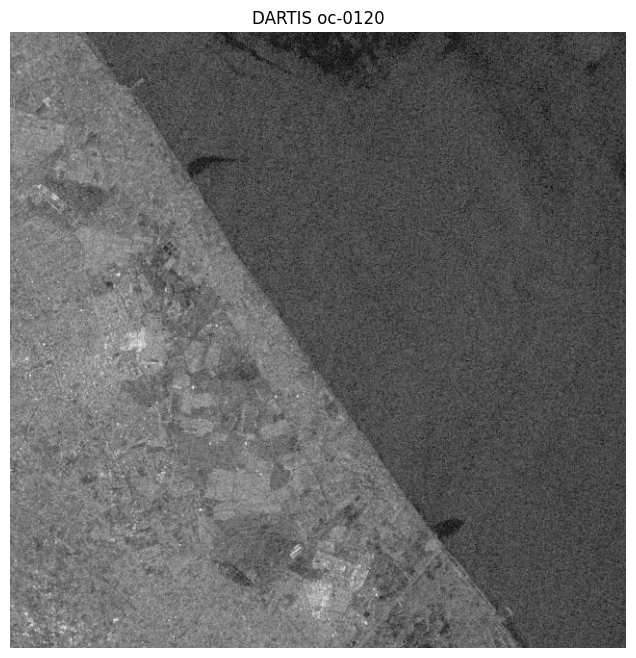

In [55]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

img_path = Path("/kaggle/working/dartis_images/oc-0120.jpg")

img = Image.open(img_path)

print("Size:", img.size)
print("Mode:", img.mode)

arr = np.array(img)

print("dtype:", arr.dtype)
print("min:", arr.min())
print("max:", arr.max())
print("shape:", arr.shape)

plt.figure(figsize=(8,8))
plt.imshow(arr, cmap="gray")
plt.axis("off")
plt.title("DARTIS oc-0120")
plt.show()

In [56]:
import pandas as pd

path = "/kaggle/working/DARTIS_2019.tab"

df = pd.read_csv(
    path,
    sep="\t",
    skiprows=49
)

row = df[df["IMAGE (jpg_file)"] == "oc-0120.jpg"]

print("Rows:", len(row))
display(row.T)

Rows: 2


,2618,2619
Image set (subset; oc : oil/coast; ow : ...),oc,oc
IMAGE (jpg_file),oc-0120.jpg,oc-0120.jpg
Binary (xml_file),oc-0120.xml,oc-0120.xml
ID (tag),oc-0120-01-000335,oc-0120-02-000336
ID (patch_name),S1_20190407_034234_034349_VV_5,S1_20190407_034234_034349_VV_5
Date/Time (start_time),2019-04-07T03:42:34,2019-04-07T03:42:34
Date/Time (end_time),2019-04-07T03:43:49,2019-04-07T03:43:49
ID (Sentinel_ID),S1B_IW_GRDH_1SDV_20190407T034324_20190407T0343...,S1B_IW_GRDH_1SDV_20190407T034324_20190407T0343...
Width [pixel] (patch_width),640,640
Height [pixel] (patch_height),640,640


In [57]:
import torch
import numpy as np
from pathlib import Path
import segmentation_models_pytorch as smp

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Find checkpoint
models = list(Path("/kaggle").rglob("unet_resnet34_best.pt"))

print("Found:", models)

MODEL_PATH = str(models[0])

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
    activation=None
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print("Model loaded:", MODEL_PATH)
print("Device:", device)

Found: [PosixPath('/kaggle/working/oil_spill_pipeline/models/unet_resnet34_best.pt')]
Model loaded: /kaggle/working/oil_spill_pipeline/models/unet_resnet34_best.pt
Device: cuda


In [58]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

img_path = "/kaggle/working/dartis_images/oc-0120.jpg"

image = np.array(
    Image.open(img_path).convert("L")
).astype(np.float32) / 255.0

H, W = image.shape

print("Image:", image.shape)

Image: (640, 640)


In [59]:
PATCH = 256
STRIDE = 128

prob_sum = np.zeros((H, W), dtype=np.float32)
count = np.zeros((H, W), dtype=np.float32)

with torch.no_grad():

    for y in range(0, H - PATCH + 1, STRIDE):
        for x in range(0, W - PATCH + 1, STRIDE):

            patch = image[
                y:y+PATCH,
                x:x+PATCH
            ]

            # Match training normalization:
            # image /255 → [0,1]
            # Normalize(mean=.5, std=.5)
            patch = (patch - 0.5) / 0.5

            tensor = torch.from_numpy(
                patch
            ).unsqueeze(0).unsqueeze(0).float().to(device)

            logits = model(tensor)
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()

            prob_sum[
                y:y+PATCH,
                x:x+PATCH
            ] += prob

            count[
                y:y+PATCH,
                x:x+PATCH
            ] += 1

prob = prob_sum / np.maximum(count, 1)

pred_mask = (prob >= 0.5).astype(np.uint8)

print("Predicted oil pixels:", pred_mask.sum())
print("Coverage:", pred_mask.mean())

Predicted oil pixels: 163189
Coverage: 0.39841064453125


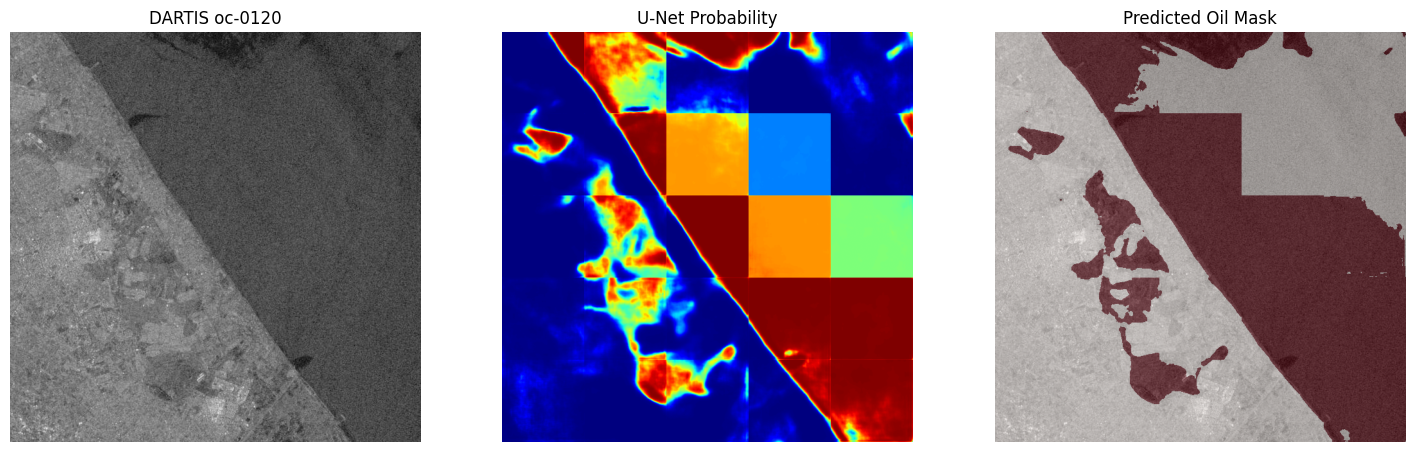

In [60]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("DARTIS oc-0120")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prob, cmap="jet")
plt.title("U-Net Probability")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(image, cmap="gray")
plt.imshow(
    pred_mask,
    cmap="Reds",
    alpha=0.45
)
plt.title("Predicted Oil Mask")
plt.axis("off")

plt.show()

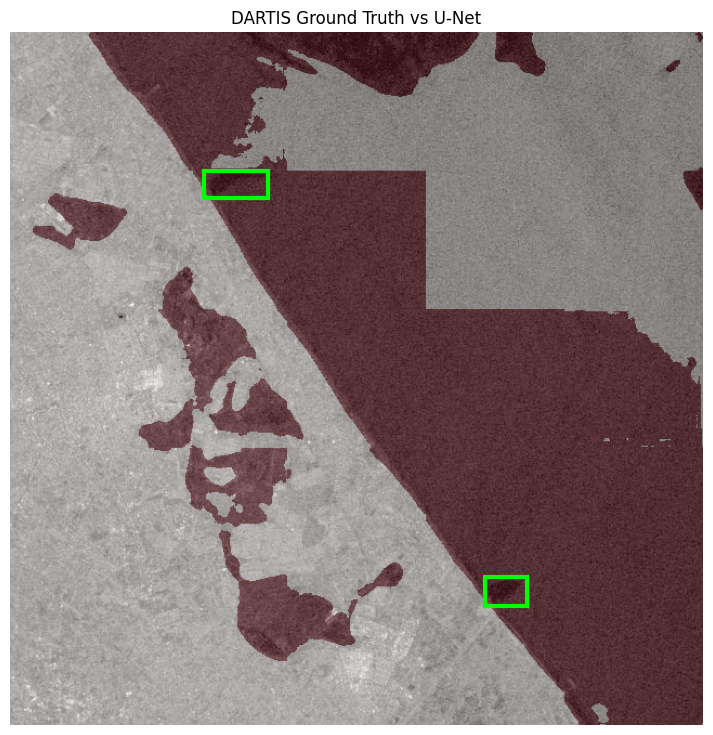

In [61]:
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(9, 9))

ax.imshow(image, cmap="gray")

# Object 1
ax.add_patch(
    patches.Rectangle(
        (438, 503),
        477 - 438,
        530 - 503,
        fill=False,
        linewidth=3,
        edgecolor="lime",
        label="DARTIS object"
    )
)

# Object 2
ax.add_patch(
    patches.Rectangle(
        (179, 128),
        238 - 179,
        153 - 128,
        fill=False,
        linewidth=3,
        edgecolor="lime"
    )
)

# Predicted mask
ax.imshow(
    pred_mask,
    cmap="Reds",
    alpha=0.35
)

ax.set_title("DARTIS Ground Truth vs U-Net")
ax.axis("off")

plt.show()

In [62]:
import numpy as np

# DARTIS ground-truth boxes
gt_boxes = [
    (438, 503, 477, 530),  # object 1
    (179, 128, 238, 153),  # object 2
]

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:

    mask = (prob >= threshold).astype(np.uint8)

    print(f"\nThreshold = {threshold}")
    print("Predicted pixels :", mask.sum())
    print("Coverage         :", mask.mean() * 100, "%")

    for i, (xmin, ymin, xmax, ymax) in enumerate(gt_boxes, 1):

        box_prob = prob[ymin:ymax+1, xmin:xmax+1]
        box_mask = mask[ymin:ymax+1, xmin:xmax+1]

        print(
            f" Object {i}: "
            f"mean_prob={box_prob.mean():.4f}, "
            f"max_prob={box_prob.max():.4f}, "
            f"positive={box_mask.mean()*100:.2f}%"
        )


Threshold = 0.5
Predicted pixels : 163189
Coverage         : 39.841064453125 %
 Object 1: mean_prob=0.9418, max_prob=0.9999, positive=98.39%
 Object 2: mean_prob=0.9613, max_prob=0.9998, positive=98.72%

Threshold = 0.6
Predicted pixels : 141447
Coverage         : 34.532958984375 %
 Object 1: mean_prob=0.9418, max_prob=0.9999, positive=98.04%
 Object 2: mean_prob=0.9613, max_prob=0.9998, positive=98.40%

Threshold = 0.7
Predicted pixels : 132420
Coverage         : 32.3291015625 %
 Object 1: mean_prob=0.9418, max_prob=0.9999, positive=96.43%
 Object 2: mean_prob=0.9613, max_prob=0.9998, positive=98.01%

Threshold = 0.8
Predicted pixels : 91429
Coverage         : 22.321533203125 %
 Object 1: mean_prob=0.9418, max_prob=0.9999, positive=94.46%
 Object 2: mean_prob=0.9613, max_prob=0.9998, positive=96.73%

Threshold = 0.9
Predicted pixels : 81522
Coverage         : 19.90283203125 %
 Object 1: mean_prob=0.9418, max_prob=0.9999, positive=86.70%
 Object 2: mean_prob=0.9613, max_prob=0.9998, p

In [63]:
def box_mask_from_boxes(shape, boxes):
    gt = np.zeros(shape, dtype=np.uint8)

    for xmin, ymin, xmax, ymax in boxes:
        gt[ymin:ymax+1, xmin:xmax+1] = 1

    return gt


gt_mask = box_mask_from_boxes(
    prob.shape,
    gt_boxes
)

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:

    pred = (prob >= threshold).astype(np.uint8)

    intersection = np.logical_and(
        pred,
        gt_mask
    ).sum()

    union = np.logical_or(
        pred,
        gt_mask
    ).sum()

    iou = intersection / union if union else 0

    print(
        f"Threshold {threshold:.1f} → "
        f"IoU = {iou:.4f}"
    )

Threshold 0.5 → IoU = 0.0162
Threshold 0.6 → IoU = 0.0186
Threshold 0.7 → IoU = 0.0197
Threshold 0.8 → IoU = 0.0280
Threshold 0.9 → IoU = 0.0297


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = np.array(
    Image.open(
        "/kaggle/working/dartis_images/oc-0120.jpg"
    ).convert("L")
).astype(np.float32) / 255.0


def run_crop(image, xmin, ymin, xmax, ymax, context=64):

    x1 = max(0, xmin - context)
    y1 = max(0, ymin - context)

    x2 = min(image.shape[1], xmax + context)
    y2 = min(image.shape[0], ymax + context)

    crop = image[y1:y2, x1:x2]

    # Resize to model input
    crop_img = Image.fromarray(
        (crop * 255).astype(np.uint8)
    ).resize((256, 256))

    crop_arr = np.asarray(crop_img).astype(np.float32) / 255.0

    # Same training normalization
    crop_arr = (crop_arr - 0.5) / 0.5

    tensor = torch.from_numpy(
        crop_arr
    ).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        probability = torch.sigmoid(
            model(tensor)
        )[0, 0].cpu().numpy()

    return crop, probability, (x1, y1, x2, y2)

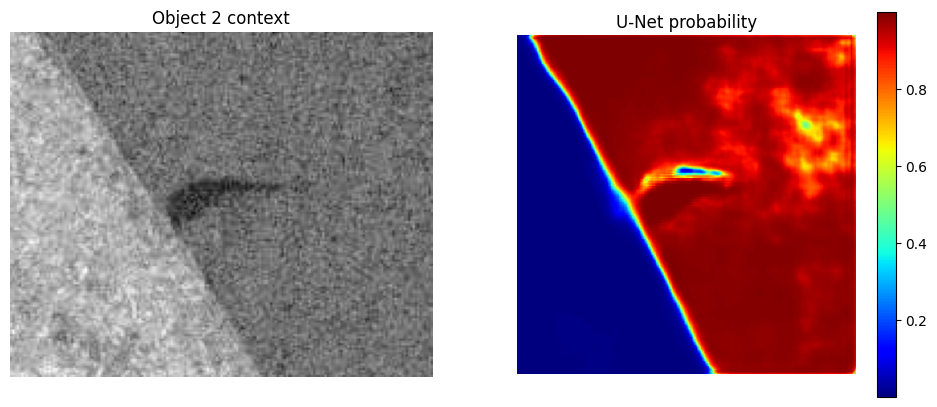

In [65]:
crop2, prob2, box2 = run_crop(
    image,
    179, 128,
    238, 153,
    context=64
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(crop2, cmap="gray")
plt.title("Object 2 context")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(prob2, cmap="jet")
plt.title("U-Net probability")
plt.colorbar()
plt.axis("off")

plt.show()

In [66]:
print("DARTIS statistics")
print("-----------------")
print("mean :", image.mean())
print("std  :", image.std())
print("p01  :", np.percentile(image, 1))
print("p50  :", np.percentile(image, 50))
print("p99  :", np.percentile(image, 99))

DARTIS statistics
-----------------
mean : 0.37356612
std  : 0.118132584
p01  : 0.14509805
p50  : 0.34509805
p99  : 0.6313726


In [67]:
from pathlib import Path
from PIL import Image
import numpy as np

# Change this if your Refined SOS validation path is different
val_images = list(
    Path("/kaggle/working").rglob("images/val/*.png")
)

print("Found validation images:", len(val_images))

sample_path = val_images[0]
sample = np.array(
    Image.open(sample_path).convert("L")
).astype(np.float32) / 255.0

print("Sample:", sample_path)
print("-------------------------------")
print("mean :", sample.mean())
print("std  :", sample.std())
print("p01  :", np.percentile(sample, 1))
print("p50  :", np.percentile(sample, 50))
print("p99  :", np.percentile(sample, 99))

Found validation images: 3230
Sample: /kaggle/working/sos_dataset/images/images/val/sentinel_179.png
-------------------------------
mean : 0.312947
std  : 0.14431135
p01  : 0.07450981
p50  : 0.28627452
p99  : 0.73333335


In [68]:
dartis_norm = (image - 0.5) / 0.5

print("DARTIS after training normalization")
print("-----------------------------------")
print("mean :", dartis_norm.mean())
print("std  :", dartis_norm.std())
print("p01  :", np.percentile(dartis_norm, 1))
print("p50  :", np.percentile(dartis_norm, 50))
print("p99  :", np.percentile(dartis_norm, 99))

DARTIS after training normalization
-----------------------------------
mean : -0.2528676
std  : 0.23626518
p01  : -0.70980394
p50  : -0.3098039
p99  : 0.26274514


In [69]:
def predict_crop(crop, mode):
    x = crop.astype(np.float32)

    if mode == "training":
        # Original training pipeline
        x = (x - 0.5) / 0.5

    elif mode == "standard":
        # Per-image standardization
        x = (x - x.mean()) / (x.std() + 1e-6)

    elif mode == "minmax":
        # Per-image min-max, then same [-1, 1] mapping
        x = (x - x.min()) / (x.max() - x.min() + 1e-6)
        x = (x - 0.5) / 0.5

    tensor = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        p = torch.sigmoid(model(tensor))[0, 0].cpu().numpy()

    return p

In [70]:
# crop2 is currently the original grayscale crop in [0,1]
crop2_256 = np.array(
    Image.fromarray((crop2 * 255).astype(np.uint8))
    .resize((256, 256))
).astype(np.float32) / 255.0

for mode in ["training", "standard", "minmax"]:
    p = predict_crop(crop2_256, mode)

    print(f"\n{mode}")
    print("mean probability:", p.mean())
    print("max probability :", p.max())
    print("pixels >= 0.5   :", (p >= 0.5).mean() * 100, "%")
    print("pixels >= 0.8   :", (p >= 0.8).mean() * 100, "%")


training
mean probability: 0.653985
max probability : 0.9999665
pixels >= 0.5   : 67.9931640625 %
pixels >= 0.8   : 65.18402099609375 %

standard
mean probability: 0.008476674
max probability : 0.8209743
pixels >= 0.5   : 0.62713623046875 %
pixels >= 0.8   : 0.00457763671875 %

minmax
mean probability: 0.45916238
max probability : 0.9999715
pixels >= 0.5   : 51.165771484375 %
pixels >= 0.8   : 23.59466552734375 %


In [71]:
# Use the standard-normalized probability map from Object 2
p_std = predict_crop(crop2_256, "standard")

# Ground-truth object 2 in the ORIGINAL 640x640 image
gt_xmin, gt_ymin = 179, 128
gt_xmax, gt_ymax = 238, 153

# Convert original coordinates into this object-centered crop's
# resized 256x256 coordinates.
x1, y1, x2, y2 = box2

scale_x = 256 / (x2 - x1)
scale_y = 256 / (y2 - y1)

gt2_xmin = max(0, int((gt_xmin - x1) * scale_x))
gt2_xmax = min(255, int((gt_xmax - x1) * scale_x))

gt2_ymin = max(0, int((gt_ymin - y1) * scale_y))
gt2_ymax = min(255, int((gt_ymax - y1) * scale_y))

gt_region = p_std[
    gt2_ymin:gt2_ymax + 1,
    gt2_xmin:gt2_xmax + 1
]

print("Object 2 under standardization:")
print("Mean probability:", gt_region.mean())
print("Max probability :", gt_region.max())
print(">=0.5           :", (gt_region >= 0.5).mean() * 100, "%")
print(">=0.8           :", (gt_region >= 0.8).mean() * 100, "%")

Object 2 under standardization:
Mean probability: 0.14939587
Max probability : 0.8209743
>=0.5           : 11.933797909407666 %
>=0.8           : 0.08710801393728224 %


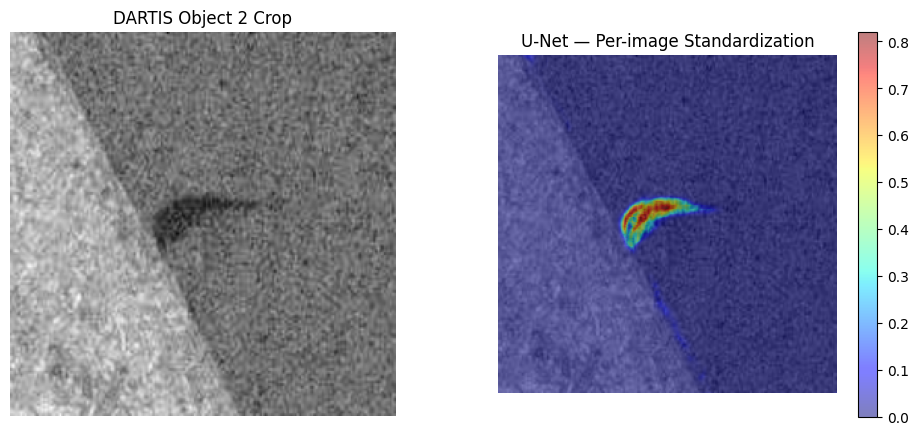

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(crop2_256, cmap="gray")
plt.title("DARTIS Object 2 Crop")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(crop2_256, cmap="gray")
plt.imshow(p_std, cmap="jet", alpha=0.5)
plt.title("U-Net — Per-image Standardization")
plt.colorbar()
plt.axis("off")

plt.show()

In [73]:
# image is your original 640x640 image in [0,1]

scene = image.copy()

# Per-image standardization
scene_std = (
    scene - scene.mean()
) / (scene.std() + 1e-6)

print("Scene standardized:")
print("mean:", scene_std.mean())
print("std :", scene_std.std())

Scene standardized:
mean: 5.340576e-07
std : 0.9999917


In [74]:
PATCH = 256
STRIDE = 128

H, W = scene_std.shape

prob_sum = np.zeros((H, W), dtype=np.float32)
count = np.zeros((H, W), dtype=np.float32)

with torch.no_grad():

    for y in range(0, H - PATCH + 1, STRIDE):
        for x in range(0, W - PATCH + 1, STRIDE):

            patch = scene_std[y:y+PATCH, x:x+PATCH]

            tensor = torch.from_numpy(
                patch
            ).unsqueeze(0).unsqueeze(0).float().to(device)

            prob_patch = torch.sigmoid(
                model(tensor)
            )[0, 0].cpu().numpy()

            prob_sum[
                y:y+PATCH,
                x:x+PATCH
            ] += prob_patch

            count[
                y:y+PATCH,
                x:x+PATCH
            ] += 1

prob_full = prob_sum / np.maximum(count, 1)

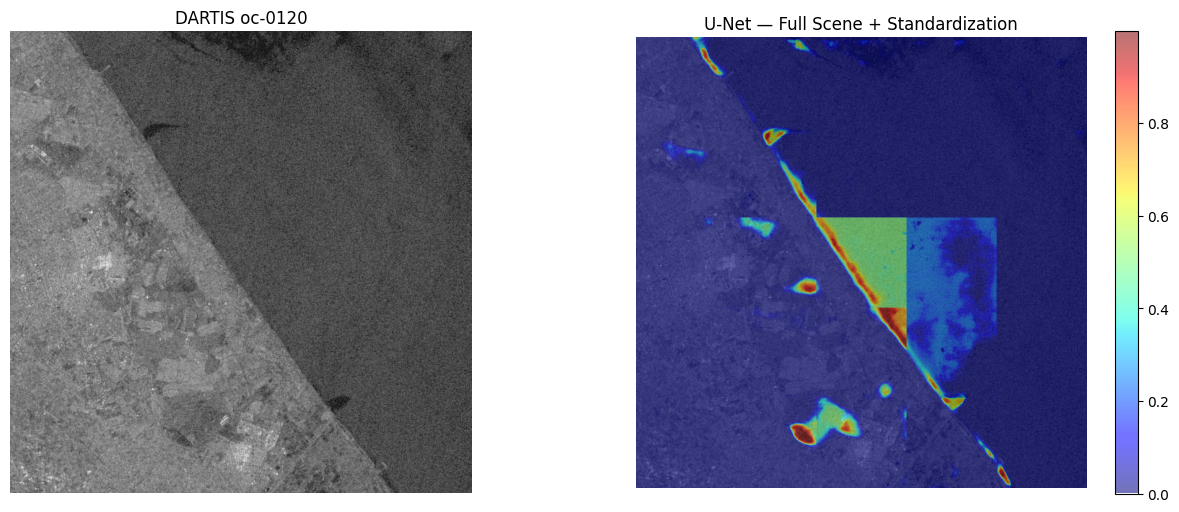

In [75]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("DARTIS oc-0120")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image, cmap="gray")
plt.imshow(prob_full, cmap="jet", alpha=0.55)
plt.title("U-Net — Full Scene + Standardization")
plt.colorbar()
plt.axis("off")

plt.show()

In [76]:
import numpy as np
import torch

PATCH = 256
STRIDE = 128

H, W = scene_std.shape

prob_sum = np.zeros((H, W), dtype=np.float32)
weight_sum = np.zeros((H, W), dtype=np.float32)

# Smooth window: low weight at tile borders, high in center
yy, xx = np.mgrid[0:PATCH, 0:PATCH]

sigma = PATCH / 6.0

window = np.exp(
    -(
        (xx - PATCH / 2) ** 2 +
        (yy - PATCH / 2) ** 2
    ) / (2 * sigma ** 2)
).astype(np.float32)

with torch.no_grad():

    for y in range(0, H - PATCH + 1, STRIDE):

        for x in range(0, W - PATCH + 1, STRIDE):

            patch = scene_std[
                y:y+PATCH,
                x:x+PATCH
            ]

            tensor = torch.from_numpy(
                patch
            ).unsqueeze(0).unsqueeze(0).float().to(device)

            p = torch.sigmoid(
                model(tensor)
            )[0, 0].cpu().numpy()

            prob_sum[
                y:y+PATCH,
                x:x+PATCH
            ] += p * window

            weight_sum[
                y:y+PATCH,
                x:x+PATCH
            ] += window

prob_blended = prob_sum / np.maximum(weight_sum, 1e-8)

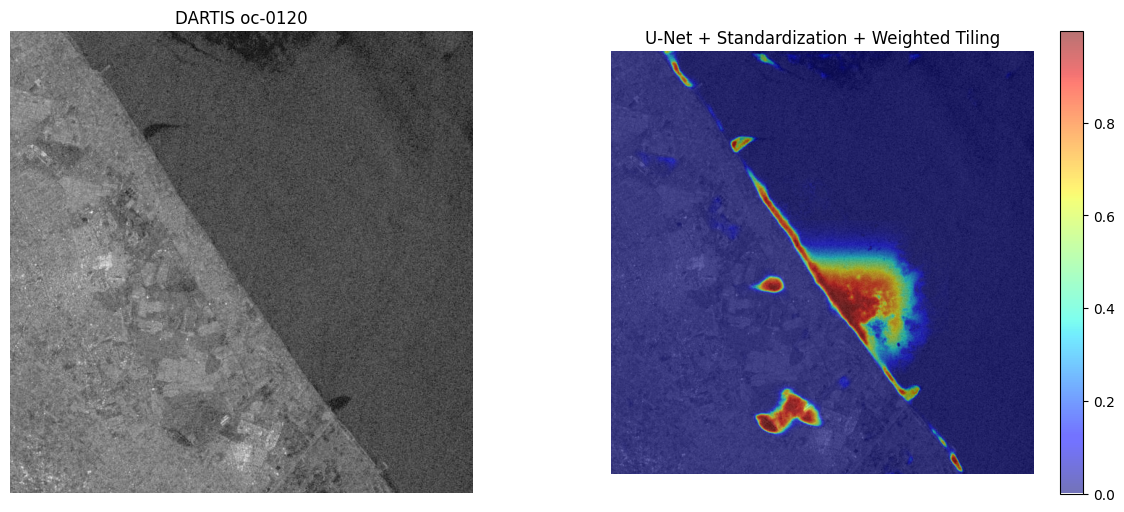

In [77]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("DARTIS oc-0120")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image, cmap="gray")
plt.imshow(prob_blended, cmap="jet", alpha=0.55)
plt.title("U-Net + Standardization + Weighted Tiling")
plt.colorbar()
plt.axis("off")

plt.show()

In [78]:
import cv2
import numpy as np

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:

    mask = (prob_blended >= threshold).astype(np.uint8)

    n, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    components = []

    for i in range(1, n):
        x, y, w, h, area = stats[i]

        if area < 20:
            continue

        cx, cy = centroids[i]

        components.append(
            (area, x, y, w, h, cx, cy)
        )

    components.sort(reverse=True)

    print(f"\nTHRESHOLD {threshold}")

    for c in components[:15]:
        print(
            f"area={c[0]:6d} "
            f"bbox=({c[1]},{c[2]},{c[3]},{c[4]}) "
            f"centroid=({c[5]:.1f},{c[6]:.1f})"
        )


THRESHOLD 0.5
area= 12698 bbox=(216,193,231,270) centroid=(367.3,357.4)
area=  2915 bbox=(219,512,96,66) centroid=(267.8,549.3)
area=   627 bbox=(222,342,39,23) centroid=(242.6,353.6)
area=   573 bbox=(411,477,56,51) centroid=(439.2,507.8)
area=   345 bbox=(182,131,31,22) centroid=(194.5,139.7)
area=   266 bbox=(92,16,28,37) centroid=(103.8,33.7)
area=   192 bbox=(514,609,17,27) centroid=(521.4,621.6)
area=    41 bbox=(227,6,9,10) centroid=(231.0,10.9)
area=    34 bbox=(498,586,8,11) centroid=(501.8,591.4)

THRESHOLD 0.6
area= 10547 bbox=(220,200,219,251) centroid=(363.7,356.6)
area=  2645 bbox=(220,513,92,65) centroid=(267.1,549.5)
area=   568 bbox=(224,343,36,21) centroid=(242.8,353.6)
area=   413 bbox=(412,478,54,49) centroid=(437.9,506.6)
area=   243 bbox=(182,132,30,20) centroid=(194.0,139.9)
area=   216 bbox=(93,16,26,36) centroid=(103.5,33.3)
area=   170 bbox=(514,610,17,25) centroid=(521.3,621.5)

THRESHOLD 0.7
area=  8244 bbox=(224,205,209,240) centroid=(358.1,356.7)
area=  2

# FINE TUNING OF THE MODEL


In [79]:
oil_df = df[df.iloc[:, 0] == "oc"].copy()

unique_images = oil_df["IMAGE (jpg_file)"].drop_duplicates()

print("Unique oil images:", len(unique_images))

Unique oil images: 375


In [80]:
selected_images = unique_images.sample(
    n=min(100, len(unique_images)),
    random_state=42
)

adapt_df = oil_df[
    oil_df["IMAGE (jpg_file)"].isin(selected_images)
].copy()

print(
    "Selected images:",
    adapt_df["IMAGE (jpg_file)"].nunique()
)

print(
    "Selected rows/objects:",
    len(adapt_df)
)

Selected images: 100
Selected rows/objects: 267


In [81]:
import numpy as np

def make_weak_mask(group):

    width = int(group["Width [pixel] (patch_width)"].iloc[0])
    height = int(group["Height [pixel] (patch_height)"].iloc[0])

    mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for _, row in group.iterrows():

        xmin = int(row["Pos X [pixel] (obj_patchloc_xmin)"])
        ymin = int(row["Pos Y [pixel] (obj_patchloc_ymin)"])
        xmax = int(row["Pos X [pixel] (obj_patchloc_xmax)"])
        ymax = int(row["Pos Y [pixel] (obj_patchloc_ymax)"])

        mask[
            ymin:ymax+1,
            xmin:xmax+1
        ] = 1

    return mask

In [82]:
import numpy as np
import cv2

def make_weak_mask(group, erosion_pixels=5):
    """
    Creates a weak segmentation target from DARTIS bounding boxes.

    0   = background
    1   = definite oil core
    255 = uncertain/ignore region
    """

    width = int(group["Width [pixel] (patch_width)"].iloc[0])
    height = int(group["Height [pixel] (patch_height)"].iloc[0])

    # Full bounding-box mask
    box_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for _, row in group.iterrows():

        xmin = int(row["Pos X [pixel] (obj_patchloc_xmin)"])
        ymin = int(row["Pos Y [pixel] (obj_patchloc_ymin)"])
        xmax = int(row["Pos X [pixel] (obj_patchloc_xmax)"])
        ymax = int(row["Pos Y [pixel] (obj_patchloc_ymax)"])

        box_mask[
            ymin:ymax + 1,
            xmin:xmax + 1
        ] = 1

    # Erode boxes to create a definite-oil core
    kernel = np.ones(
        (3, 3),
        dtype=np.uint8
    )

    core_mask = cv2.erode(
        box_mask,
        kernel,
        iterations=erosion_pixels
    )

    # Final weak target
    target = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    # Entire box is uncertain
    target[box_mask == 1] = 255

    # Inner core is definite oil
    target[core_mask == 1] = 1

    return target

In [83]:
group = df[
    df["IMAGE (jpg_file)"] == "oc-0120.jpg"
]

weak_mask = make_weak_mask(group)

print("Background:", np.sum(weak_mask == 0))
print("Oil core  :", np.sum(weak_mask == 1))
print("Ignore    :", np.sum(weak_mask == 255))

Background: 406920
Oil core  : 1340
Ignore    : 1340


Background: 406920
Positive oil core: 2096
Ignore region: 584


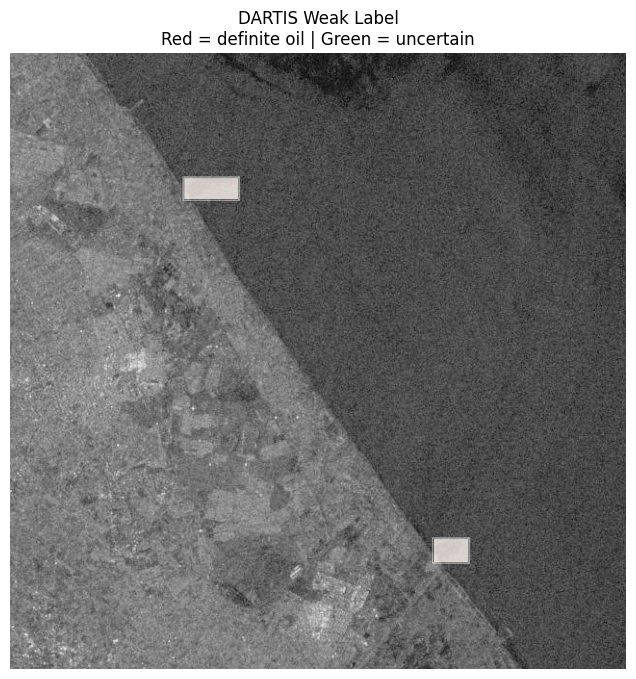

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Create the weak mask FIRST
weak_mask = make_weak_mask(
    group,
    erosion_pixels=2
)

# Now define the regions
ignore = weak_mask == 255
positive = weak_mask == 1

print("Background:", np.sum(weak_mask == 0))
print("Positive oil core:", np.sum(weak_mask == 1))
print("Ignore region:", np.sum(weak_mask == 255))

plt.figure(figsize=(8, 8))

plt.imshow(
    image,
    cmap="gray"
)

# Green = uncertain bounding-box area
plt.imshow(
    np.ma.masked_where(
        ~ignore,
        ignore
    ),
    cmap="Greens",
    alpha=0.45
)

# Red = definite oil core
plt.imshow(
    np.ma.masked_where(
        ~positive,
        positive
    ),
    cmap="Reds",
    alpha=0.8
)

plt.title(
    "DARTIS Weak Label\n"
    "Red = definite oil | Green = uncertain"
)

plt.axis("off")
plt.show()

## RETRAINING

In [85]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np

class DARTISDataset(Dataset):

    def __init__(self, dataframe, image_dir):
        self.df = dataframe.copy()
        self.image_dir = image_dir

        self.images = (
            self.df["IMAGE (jpg_file)"]
            .drop_duplicates()
            .tolist()
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        filename = self.images[idx]

        image = np.array(
            Image.open(
                f"{self.image_dir}/{filename}"
            ).convert("L")
        ).astype(np.float32) / 255.0

        # DARTIS domain normalization
        image = (
            image - image.mean()
        ) / (
            image.std() + 1e-6
        )

        group = self.df[
            self.df["IMAGE (jpg_file)"] == filename
        ]

        target = make_weak_mask(
            group,
            erosion_pixels=2
        )

        # Model expects 256 × 256
        image = Image.fromarray(
            image.astype(np.float32),
            mode="F"
        ).resize((256, 256))

        image = np.array(image)

        # Resize target using nearest-neighbour
        target = Image.fromarray(
            target
        ).resize(
            (256, 256),
            resample=Image.Resampling.NEAREST
        )

        target = np.array(target)

        return (
            torch.tensor(
                image,
                dtype=torch.float32
            ).unsqueeze(0),

            torch.tensor(
                target,
                dtype=torch.long
            )
        )

In [86]:
from pathlib import Path

image_dir = Path("/kaggle/working/dartis_images")

downloaded_images = sorted(image_dir.glob("*.jpg"))

print("Downloaded JPGs:", len(downloaded_images))

for p in downloaded_images:
    print(p.name)

Downloaded JPGs: 10
oc-0008.jpg
oc-0011.jpg
oc-0120.jpg
oc-0134.jpg
oc-0152.jpg
oc-0201.jpg
oc-0202.jpg
oc-0203.jpg
oc-0227.jpg
oc-0291.jpg


In [87]:
downloaded_names = [p.name for p in downloaded_images]

current_df = df[
    df["IMAGE (jpg_file)"].isin(downloaded_names)
].copy()

print("Metadata rows:", len(current_df))
print(
    "Unique images:",
    current_df["IMAGE (jpg_file)"].nunique()
)
print(
    "Unique Sentinel products:",
    current_df["ID (Sentinel_ID)"].nunique()
)

Metadata rows: 29
Unique images: 10
Unique Sentinel products: 9


In [88]:
geo_cols = [
    "Date/Time (start_time)",
    "Date/Time (end_time)",
    "ID (Sentinel_ID)",

    "Longitude (patch_ul_lon)",
    "Latitude (patch_ul_lat)",
    "Longitude (patch_ur_lon)",
    "Latitude (patch_ur_lat)",
    "Longitude (patch_br_lon)",
    "Latitude (patch_br_lat)",
    "Longitude (patch_bl_lon)",
    "Latitude (patch_bl_lat)",

    "Longitude (obj_ul_lon)",
    "Latitude (obj_ul_lat)",
    "Longitude (obj_ur_lon)",
    "Latitude (obj_ur_lat)",
    "Longitude (obj_br_lon)",
    "Latitude (obj_br_lat)",
    "Longitude (obj_bl_lon)",
    "Latitude (obj_bl_lat)",

    "Pos X [pixel] (obj_patchloc_xmin)",
    "Pos Y [pixel] (obj_patchloc_ymin)",
    "Pos X [pixel] (obj_patchloc_xmax)",
    "Pos Y [pixel] (obj_patchloc_ymax)",
]

missing = current_df[geo_cols].isna().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Series([], dtype: int64)


In [89]:
inventory = (
    current_df
    .groupby("IMAGE (jpg_file)")
    .agg(
        sentinel_id=("ID (Sentinel_ID)", "first"),
        start_time=("Date/Time (start_time)", "first"),
        end_time=("Date/Time (end_time)", "first"),
        width=("Width [pixel] (patch_width)", "first"),
        height=("Height [pixel] (patch_height)", "first"),
        oil_objects=("ID (tag)", "count")
    )
    .reset_index()
    .sort_values("IMAGE (jpg_file)")
)

display(inventory)

,IMAGE (jpg_file),sentinel_id,start_time,end_time,width,height,oil_objects
0,oc-0008.jpg,S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...,2019-01-10T15:56:11,2019-01-10T15:56:35,640,640,5
1,oc-0011.jpg,S1B_IW_GRDH_1SDV_20190113T034235_20190113T0343...,2019-01-13T03:42:35,2019-01-13T03:43:50,640,640,7
2,oc-0120.jpg,S1B_IW_GRDH_1SDV_20190407T034324_20190407T0343...,2019-04-07T03:42:34,2019-04-07T03:43:49,640,640,2
3,oc-0134.jpg,S1B_IW_GRDH_1SDV_20190423T154811_20190423T1548...,2019-04-23T15:47:46,2019-04-23T15:49:26,640,640,2
4,oc-0152.jpg,S1A_IW_GRDH_1SDV_20190519T034414_20190519T0344...,2019-05-19T03:42:59,2019-05-19T03:44:39,640,640,1
5,oc-0201.jpg,S1A_IW_GRDH_1SDV_20190703T155707_20190703T1557...,2019-07-03T15:56:42,2019-07-03T15:58:22,640,640,1
6,oc-0202.jpg,S1A_IW_GRDH_1SDV_20190703T155707_20190703T1557...,2019-07-03T15:56:42,2019-07-03T15:58:22,640,640,3
7,oc-0203.jpg,S1B_IW_GRDH_1SDV_20190704T154815_20190704T1548...,2019-07-04T15:47:50,2019-07-04T15:49:30,640,640,3
8,oc-0227.jpg,S1B_IW_GRDH_1SDV_20190729T035201_20190729T0352...,2019-07-29T03:50:46,2019-07-29T03:52:25,640,640,1
9,oc-0291.jpg,S1B_IW_GRDH_1SDV_20191001T155619_20191001T1556...,2019-10-01T15:56:19,2019-10-01T15:56:44,1371,1371,4


In [90]:
oil_df = df[df.iloc[:, 0] == "oc"].copy()

print("Oil annotation rows:", len(oil_df))
print("Unique oil images:", oil_df["IMAGE (jpg_file)"].nunique())

Oil annotation rows: 941
Unique oil images: 375


In [91]:
image_level = (
    oil_df.groupby("IMAGE (jpg_file)")
    .agg(
        sentinel_id=("ID (Sentinel_ID)", "first"),
        start_time=("Date/Time (start_time)", "first"),
        end_time=("Date/Time (end_time)", "first"),
        width=("Width [pixel] (patch_width)", "first"),
        height=("Height [pixel] (patch_height)", "first")
    )
    .reset_index()
)

print("Total DARTIS oil images available:", len(image_level))
print(
    "Unique Sentinel products:",
    image_level["sentinel_id"].nunique()
)

Total DARTIS oil images available: 375
Unique Sentinel products: 281


In [92]:
product_counts = (
    image_level["sentinel_id"]
    .value_counts()
)

print(product_counts.head(20))

sentinel_id
S1B_IW_GRDH_1SDV_20191130T155618_20191130T155643_019159_02429A_7E10.SAFE    7
S1B_IW_GRDH_1SDV_20190404T155610_20190404T155635_015659_01D5E2_CCBC.SAFE    6
S1B_IW_GRDH_1SDV_20190223T035130_20190223T035155_015068_01C287_0DC8.SAFE    4
S1B_IW_GRDH_1SDV_20191001T155619_20191001T155644_018284_0226F2_D309.SAFE    4
S1A_IW_GRDH_1SDV_20190410T155702_20190410T155727_026730_030069_18D5.SAFE    4
S1A_IW_GRDH_1SDV_20191031T155712_20191031T155737_029705_036271_F756.SAFE    4
S1B_IW_GRDH_1SDV_20190817T034250_20190817T034315_017620_021260_0DF6.SAFE    3
S1A_IW_GRDH_1SDV_20190224T034412_20190224T034437_026066_02E816_BEB1.SAFE    3
S1A_IW_GRDH_1SDV_20190519T034414_20190519T034439_027291_0313E1_23BF.SAFE    3
S1A_IW_GRDH_1SDV_20190523T154838_20190523T154903_027357_0315EA_5427.SAFE    3
S1B_IW_GRDH_1SDV_20191109T034342_20191109T034407_018845_0238A3_42C2.SAFE    3
S1A_IW_GRDH_1SDV_20190320T034412_20190320T034437_026416_02F4D4_1A96.SAFE    3
S1B_IW_GRDH_1SDV_20190615T155613_20190615T155638_016

In [93]:
from pathlib import Path

image_dir = Path("/kaggle/working/dartis_images")

downloaded = sorted(
    p.name for p in image_dir.glob("*.jpg")
)

print("Currently downloaded:", len(downloaded))

print("\nDownloaded files:")
for f in downloaded:
    print(f)

Currently downloaded: 10

Downloaded files:
oc-0008.jpg
oc-0011.jpg
oc-0120.jpg
oc-0134.jpg
oc-0152.jpg
oc-0201.jpg
oc-0202.jpg
oc-0203.jpg
oc-0227.jpg
oc-0291.jpg


In [94]:
print("Total oil annotation rows :", len(oil_df))
print("Total unique oil images   :", oil_df["IMAGE (jpg_file)"].nunique())
print("Total unique Sentinel IDs :", oil_df["ID (Sentinel_ID)"].nunique())

Total oil annotation rows : 941
Total unique oil images   : 375
Total unique Sentinel IDs : 281


In [95]:
print(
    oil_df["ID (Sentinel_ID)"]
    .nunique()
)

print(
    oil_df[
        ["IMAGE (jpg_file)", "ID (Sentinel_ID)"]
    ]
    .drop_duplicates()
    .head(20)
)

281
     IMAGE (jpg_file)                                   ID (Sentinel_ID)
2284      oc-0001.jpg  S1B_IW_GRDH_1SDV_20190101T034235_20190101T0343...
2289      oc-0002.jpg  S1B_IW_GRDH_1SDV_20190101T034325_20190101T0343...
2291      oc-0003.jpg  S1B_IW_GRDH_1SDV_20190101T034325_20190101T0343...
2292      oc-0004.jpg  S1A_IW_GRDH_1SDV_20190104T155703_20190104T1557...
2294      oc-0005.jpg  S1A_IW_GRDH_1SDV_20190105T040043_20190105T0401...
2295      oc-0006.jpg  S1B_IW_GRDH_1SDV_20190105T154811_20190105T1548...
2297      oc-0007.jpg  S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...
2304      oc-0008.jpg  S1B_IW_GRDH_1SDV_20190110T155611_20190110T1556...
2309      oc-0009.jpg  S1A_IW_GRDH_1SDV_20190111T154836_20190111T1549...
2310      oc-0010.jpg  S1B_IW_GRDH_1SDV_20190113T034235_20190113T0343...
2311      oc-0011.jpg  S1B_IW_GRDH_1SDV_20190113T034235_20190113T0343...
2318      oc-0012.jpg  S1B_IW_GRDH_1SDV_20190113T034300_20190113T0343...
2322      oc-0013.jpg  S1B_IW_GRDH_1SDV_2019011

In [96]:
from sklearn.model_selection import train_test_split

# One row per unique image
image_level = (
    oil_df
    .groupby("IMAGE (jpg_file)")
    .agg(
        sentinel_id=("ID (Sentinel_ID)", "first"),
        start_time=("Date/Time (start_time)", "first"),
        end_time=("Date/Time (end_time)", "first"),
        width=("Width [pixel] (patch_width)", "first"),
        height=("Height [pixel] (patch_height)", "first")
    )
    .reset_index()
)

print("Unique oil images:", len(image_level))
print("Unique Sentinel products:", image_level["sentinel_id"].nunique())

# Split Sentinel products
products = image_level["sentinel_id"].unique()

train_products, temp_products = train_test_split(
    products,
    test_size=0.30,
    random_state=42
)

val_products, test_products = train_test_split(
    temp_products,
    test_size=0.50,
    random_state=42
)

train_pool = image_level[
    image_level["sentinel_id"].isin(train_products)
].copy()

val_pool = image_level[
    image_level["sentinel_id"].isin(val_products)
].copy()

test_pool = image_level[
    image_level["sentinel_id"].isin(test_products)
].copy()

print("\nProduct split:")
print("Train products:", len(train_products))
print("Val products  :", len(val_products))
print("Test products :", len(test_products))

print("\nImage pool:")
print("Train images:", len(train_pool))
print("Val images  :", len(val_pool))
print("Test images :", len(test_pool))

Unique oil images: 375
Unique Sentinel products: 281

Product split:
Train products: 196
Val products  : 42
Test products : 43

Image pool:
Train images: 264
Val images  : 53
Test images : 58


In [97]:
train_selected = train_pool.copy()
val_selected   = val_pool.copy()
test_selected  = test_pool.copy()

print("Adaptation images:", len(train_selected))
print("Validation images:", len(val_selected))
print("Test images:", len(test_selected))

Adaptation images: 264
Validation images: 53
Test images: 58


In [98]:
selected_names = (
    set(train_selected["IMAGE (jpg_file)"]) |
    set(val_selected["IMAGE (jpg_file)"]) |
    set(test_selected["IMAGE (jpg_file)"])
)

selected_df = oil_df[
    oil_df["IMAGE (jpg_file)"].isin(selected_names)
].copy()

from pathlib import Path

image_dir = Path("/kaggle/working/dartis_images")
image_dir.mkdir(exist_ok=True)

existing = {
    p.name for p in image_dir.glob("*.jpg")
}

needed = sorted(selected_names - existing)

print("Selected images:", len(selected_names))
print("Already downloaded:", len(existing))
print("Need to download:", len(needed))

Selected images: 375
Already downloaded: 10
Need to download: 365


In [99]:
import requests
from tqdm.auto import tqdm

for filename in tqdm(needed):

    url = (
        "https://download.pangaea.de/dataset/980773/files/"
        + filename
    )

    out_path = image_dir / filename

    if out_path.exists():
        continue

    try:
        r = requests.get(url, timeout=60)

        if r.status_code == 200:
            out_path.write_bytes(r.content)
        else:
            print(
                f"FAILED {filename}: HTTP {r.status_code}"
            )

    except Exception as e:
        print(f"ERROR {filename}: {e}")

  0%|          | 0/365 [00:00<?, ?it/s]

In [100]:
downloaded = {
    p.name for p in image_dir.glob("*.jpg")
}

print("Downloaded:", len(downloaded))
print("Missing:", len(selected_names - downloaded))

Downloaded: 375
Missing: 0


# checking leakage

In [101]:

from sklearn.model_selection import train_test_split

oil_df = df[df.iloc[:, 0] == "oc"].copy()

image_level = (
    oil_df.groupby("IMAGE (jpg_file)")
    .agg(
        sentinel_id=("ID (Sentinel_ID)", "first"),
        start_time=("Date/Time (start_time)", "first"),
        end_time=("Date/Time (end_time)", "first"),
        width=("Width [pixel] (patch_width)", "first"),
        height=("Height [pixel] (patch_height)", "first")
    )
    .reset_index()
)

products = image_level["sentinel_id"].unique()

train_products, temp_products = train_test_split(
    products,
    test_size=0.30,
    random_state=42
)

val_products, test_products = train_test_split(
    temp_products,
    test_size=0.50,
    random_state=42
)

train_selected = image_level[
    image_level["sentinel_id"].isin(train_products)
].copy()

val_selected = image_level[
    image_level["sentinel_id"].isin(val_products)
].copy()

test_selected = image_level[
    image_level["sentinel_id"].isin(test_products)
].copy()

print("Train:", len(train_selected), "images")
print("Val  :", len(val_selected), "images")
print("Test :", len(test_selected), "images")

print("\nProducts:")
print("Train:", len(train_products))
print("Val  :", len(val_products))
print("Test :", len(test_products))

Train: 264 images
Val  : 53 images
Test : 58 images

Products:
Train: 196
Val  : 42
Test : 43


In [102]:
train_names = set(train_selected["IMAGE (jpg_file)"])
val_names = set(val_selected["IMAGE (jpg_file)"])
test_names = set(test_selected["IMAGE (jpg_file)"])

print("Image leakage:")
print("Train ∩ Val :", len(train_names & val_names))
print("Train ∩ Test:", len(train_names & test_names))
print("Val ∩ Test  :", len(val_names & test_names))

train_products_set = set(train_selected["sentinel_id"])
val_products_set = set(val_selected["sentinel_id"])
test_products_set = set(test_selected["sentinel_id"])

print("\nProduct leakage:")
print("Train ∩ Val :", len(train_products_set & val_products_set))
print("Train ∩ Test:", len(train_products_set & test_products_set))
print("Val ∩ Test  :", len(val_products_set & test_products_set))

Image leakage:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Product leakage:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0


In [103]:
train_df = oil_df[
    oil_df["IMAGE (jpg_file)"].isin(train_names)
].copy()

val_df = oil_df[
    oil_df["IMAGE (jpg_file)"].isin(val_names)
].copy()

test_df = oil_df[
    oil_df["IMAGE (jpg_file)"].isin(test_names)
].copy()

print("Train images :", train_df["IMAGE (jpg_file)"].nunique())
print("Val images   :", val_df["IMAGE (jpg_file)"].nunique())
print("Test images  :", test_df["IMAGE (jpg_file)"].nunique())

print("Train objects:", len(train_df))
print("Val objects  :", len(val_df))
print("Test objects :", len(test_df))

Train images : 264
Val images   : 53
Test images  : 58
Train objects: 669
Val objects  : 146
Test objects : 126


In [104]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torch
import cv2
from pathlib import Path


def make_weak_mask(group, erosion_pixels=2):

    width = int(group["Width [pixel] (patch_width)"].iloc[0])
    height = int(group["Height [pixel] (patch_height)"].iloc[0])

    box_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for _, row in group.iterrows():

        xmin = int(row["Pos X [pixel] (obj_patchloc_xmin)"])
        ymin = int(row["Pos Y [pixel] (obj_patchloc_ymin)"])
        xmax = int(row["Pos X [pixel] (obj_patchloc_xmax)"])
        ymax = int(row["Pos Y [pixel] (obj_patchloc_ymax)"])

        box_mask[
            ymin:ymax + 1,
            xmin:xmax + 1
        ] = 1

    kernel = np.ones((3, 3), dtype=np.uint8)

    core = cv2.erode(
        box_mask,
        kernel,
        iterations=erosion_pixels
    )

    target = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    # Uncertain annotation box
    target[box_mask == 1] = 255

    # Definite oil core
    target[core == 1] = 1

    return target


class DARTISObjectDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        crop_size=256,
        return_metadata=True
    ):
        self.df = dataframe.copy()
        self.image_dir = Path(image_dir)
        self.crop_size = crop_size
        self.return_metadata = return_metadata

        # One sample per annotated object
        self.samples = []

        for filename, group in self.df.groupby(
            "IMAGE (jpg_file)"
        ):

            for _, row in group.iterrows():

                self.samples.append({
                    "filename": filename,

                    "xmin": int(
                        row["Pos X [pixel] (obj_patchloc_xmin)"]
                    ),
                    "ymin": int(
                        row["Pos Y [pixel] (obj_patchloc_ymin)"]
                    ),
                    "xmax": int(
                        row["Pos X [pixel] (obj_patchloc_xmax)"]
                    ),
                    "ymax": int(
                        row["Pos Y [pixel] (obj_patchloc_ymax)"]
                    ),

                    "tag": row["ID (tag)"],
                    "patch_name": row["ID (patch_name)"],
                    "sentinel_id": row["ID (Sentinel_ID)"],

                    "start_time": row[
                        "Date/Time (start_time)"
                    ],
                    "end_time": row[
                        "Date/Time (end_time)"
                    ],

                    # Patch geographic corners
                    "patch_ul_lon": float(
                        row["Longitude (patch_ul_lon)"]
                    ),
                    "patch_ul_lat": float(
                        row["Latitude (patch_ul_lat)"]
                    ),
                    "patch_ur_lon": float(
                        row["Longitude (patch_ur_lon)"]
                    ),
                    "patch_ur_lat": float(
                        row["Latitude (patch_ur_lat)"]
                    ),
                    "patch_br_lon": float(
                        row["Longitude (patch_br_lon)"]
                    ),
                    "patch_br_lat": float(
                        row["Latitude (patch_br_lat)"]
                    ),
                    "patch_bl_lon": float(
                        row["Longitude (patch_bl_lon)"]
                    ),
                    "patch_bl_lat": float(
                        row["Latitude (patch_bl_lat)"]
                    ),

                    # Object geographic corners
                    "obj_ul_lon": float(
                        row["Longitude (obj_ul_lon)"]
                    ),
                    "obj_ul_lat": float(
                        row["Latitude (obj_ul_lat)"]
                    ),
                    "obj_ur_lon": float(
                        row["Longitude (obj_ur_lon)"]
                    ),
                    "obj_ur_lat": float(
                        row["Latitude (obj_ur_lat)"]
                    ),
                    "obj_br_lon": float(
                        row["Longitude (obj_br_lon)"]
                    ),
                    "obj_br_lat": float(
                        row["Latitude (obj_br_lat)"]
                    ),
                    "obj_bl_lon": float(
                        row["Longitude (obj_bl_lon)"]
                    ),
                    "obj_bl_lat": float(
                        row["Latitude (obj_bl_lat)"]
                    )
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]
        filename = sample["filename"]

        # -----------------------------
        # Load image
        # -----------------------------

        image = np.array(
            Image.open(
                self.image_dir / filename
            ).convert("L")
        ).astype(np.float32) / 255.0

        # DARTIS domain normalization
        image = (
            image - image.mean()
        ) / (
            image.std() + 1e-6
        )

        # -----------------------------
        # Full weak mask
        # -----------------------------

        group = self.df[
            self.df["IMAGE (jpg_file)"] == filename
        ]

        full_mask = make_weak_mask(
            group,
            erosion_pixels=2
        )

        # -----------------------------
        # Object center
        # -----------------------------

        cx = (
            sample["xmin"] +
            sample["xmax"]
        ) // 2

        cy = (
            sample["ymin"] +
            sample["ymax"]
        ) // 2

        half = self.crop_size // 2

        # Crop around object
        x1 = cx - half
        y1 = cy - half
        x2 = x1 + self.crop_size
        y2 = y1 + self.crop_size

        # -----------------------------
        # Boundary padding
        # -----------------------------

        pad_left = max(0, -x1)
        pad_top = max(0, -y1)
        pad_right = max(
            0,
            x2 - image.shape[1]
        )
        pad_bottom = max(
            0,
            y2 - image.shape[0]
        )

        if any([
            pad_left,
            pad_top,
            pad_right,
            pad_bottom
        ]):

            image = np.pad(
                image,
                (
                    (pad_top, pad_bottom),
                    (pad_left, pad_right)
                ),
                mode="reflect"
            )

            full_mask = np.pad(
                full_mask,
                (
                    (pad_top, pad_bottom),
                    (pad_left, pad_right)
                ),
                mode="constant",
                constant_values=0
            )

            x1 += pad_left
            y1 += pad_top
            x2 += pad_left
            y2 += pad_top

        image_crop = image[
            y1:y2,
            x1:x2
        ]

        mask_crop = full_mask[
            y1:y2,
            x1:x2
        ]

        # Save original-image coordinates of crop
        sample["crop_origin_x"] = x1
        sample["crop_origin_y"] = y1

        # -----------------------------
        # Tensor conversion
        # -----------------------------

        image_tensor = torch.from_numpy(
            image_crop
        ).unsqueeze(0).float()

        mask_tensor = torch.from_numpy(
            mask_crop
        ).long()

        if self.return_metadata:

            return {
                "image": image_tensor,
                "mask": mask_tensor,
                "metadata": sample
            }

        return image_tensor, mask_tensor

# creating loaders

In [105]:
# ==========================================
# REBUILD DARTIS DATASETS + DATALOADERS
# ==========================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path

import numpy as np
import torch
import cv2


# ------------------------------------------
# 1. Weak-label function
# ------------------------------------------

def make_weak_mask(group, erosion_pixels=2):

    width = int(
        group["Width [pixel] (patch_width)"].iloc[0]
    )

    height = int(
        group["Height [pixel] (patch_height)"].iloc[0]
    )

    box_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for _, row in group.iterrows():

        xmin = int(row[
            "Pos X [pixel] (obj_patchloc_xmin)"
        ])

        ymin = int(row[
            "Pos Y [pixel] (obj_patchloc_ymin)"
        ])

        xmax = int(row[
            "Pos X [pixel] (obj_patchloc_xmax)"
        ])

        ymax = int(row[
            "Pos Y [pixel] (obj_patchloc_ymax)"
        ])

        box_mask[
            ymin:ymax + 1,
            xmin:xmax + 1
        ] = 1

    kernel = np.ones(
        (3, 3),
        dtype=np.uint8
    )

    core = cv2.erode(
        box_mask,
        kernel,
        iterations=erosion_pixels
    )

    target = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    # uncertain annotation region
    target[box_mask == 1] = 255

    # definite oil core
    target[core == 1] = 1

    return target


# ------------------------------------------
# 2. Dataset
# ------------------------------------------

class DARTISObjectDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        crop_size=256
    ):

        self.df = dataframe.copy()
        self.image_dir = Path(image_dir)
        self.crop_size = crop_size

        self.samples = []

        for filename, group in self.df.groupby(
            "IMAGE (jpg_file)"
        ):

            for _, row in group.iterrows():

                self.samples.append({
                    "filename": filename,

                    "xmin": int(row[
                        "Pos X [pixel] (obj_patchloc_xmin)"
                    ]),
                    "ymin": int(row[
                        "Pos Y [pixel] (obj_patchloc_ymin)"
                    ]),
                    "xmax": int(row[
                        "Pos X [pixel] (obj_patchloc_xmax)"
                    ]),
                    "ymax": int(row[
                        "Pos Y [pixel] (obj_patchloc_ymax)"
                    ]),

                    "tag": row["ID (tag)"],
                    "patch_name": row["ID (patch_name)"],
                    "sentinel_id": row["ID (Sentinel_ID)"],

                    "start_time": row[
                        "Date/Time (start_time)"
                    ],
                    "end_time": row[
                        "Date/Time (end_time)"
                    ],

                    "patch_ul_lon": float(
                        row["Longitude (patch_ul_lon)"]
                    ),
                    "patch_ul_lat": float(
                        row["Latitude (patch_ul_lat)"]
                    ),
                    "patch_ur_lon": float(
                        row["Longitude (patch_ur_lon)"]
                    ),
                    "patch_ur_lat": float(
                        row["Latitude (patch_ur_lat)"]
                    ),
                    "patch_br_lon": float(
                        row["Longitude (patch_br_lon)"]
                    ),
                    "patch_br_lat": float(
                        row["Latitude (patch_br_lat)"]
                    ),
                    "patch_bl_lon": float(
                        row["Longitude (patch_bl_lon)"]
                    ),
                    "patch_bl_lat": float(
                        row["Latitude (patch_bl_lat)"]
                    ),

                    "obj_ul_lon": float(
                        row["Longitude (obj_ul_lon)"]
                    ),
                    "obj_ul_lat": float(
                        row["Latitude (obj_ul_lat)"]
                    ),
                    "obj_ur_lon": float(
                        row["Longitude (obj_ur_lon)"]
                    ),
                    "obj_ur_lat": float(
                        row["Latitude (obj_ur_lat)"]
                    ),
                    "obj_br_lon": float(
                        row["Longitude (obj_br_lon)"]
                    ),
                    "obj_br_lat": float(
                        row["Latitude (obj_br_lat)"]
                    ),
                    "obj_bl_lon": float(
                        row["Longitude (obj_bl_lon)"]
                    ),
                    "obj_bl_lat": float(
                        row["Latitude (obj_bl_lat)"]
                    )
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]
        filename = sample["filename"]

        # -----------------------------
        # Load + standardize image
        # -----------------------------

        image = np.array(
            Image.open(
                self.image_dir / filename
            ).convert("L")
        ).astype(np.float32) / 255.0

        image = (
            image - image.mean()
        ) / (
            image.std() + 1e-6
        )

        # -----------------------------
        # Full weak mask
        # -----------------------------

        group = self.df[
            self.df["IMAGE (jpg_file)"] == filename
        ]

        full_mask = make_weak_mask(
            group,
            erosion_pixels=2
        )

        # -----------------------------
        # Object center
        # -----------------------------

        cx = (
            sample["xmin"] +
            sample["xmax"]
        ) // 2

        cy = (
            sample["ymin"] +
            sample["ymax"]
        ) // 2

        half = self.crop_size // 2

        x1 = cx - half
        y1 = cy - half
        x2 = x1 + self.crop_size
        y2 = y1 + self.crop_size

        # -----------------------------
        # Boundary padding
        # -----------------------------

        pad_left = max(0, -x1)
        pad_top = max(0, -y1)

        pad_right = max(
            0,
            x2 - image.shape[1]
        )

        pad_bottom = max(
            0,
            y2 - image.shape[0]
        )

        if any([
            pad_left,
            pad_top,
            pad_right,
            pad_bottom
        ]):

            image = np.pad(
                image,
                (
                    (pad_top, pad_bottom),
                    (pad_left, pad_right)
                ),
                mode="reflect"
            )

            full_mask = np.pad(
                full_mask,
                (
                    (pad_top, pad_bottom),
                    (pad_left, pad_right)
                ),
                mode="constant",
                constant_values=0
            )

            x1 += pad_left
            y1 += pad_top
            x2 += pad_left
            y2 += pad_top

        image_crop = image[
            y1:y2,
            x1:x2
        ]

        mask_crop = full_mask[
            y1:y2,
            x1:x2
        ]

        # Save crop origin for geolocation later
        sample["crop_origin_x"] = x1
        sample["crop_origin_y"] = y1

        return {
            "image": torch.from_numpy(
                image_crop
            ).unsqueeze(0).float(),

            "mask": torch.from_numpy(
                mask_crop
            ).long(),

            "metadata": sample
        }


# ------------------------------------------
# 3. Build datasets
# ------------------------------------------

dartis_train = DARTISObjectDataset(
    train_df,
    image_dir
)

dartis_val = DARTISObjectDataset(
    val_df,
    image_dir
)

dartis_test = DARTISObjectDataset(
    test_df,
    image_dir
)


# ------------------------------------------
# 4. Build loaders
# ------------------------------------------

train_loader = DataLoader(
    dartis_train,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    dartis_val,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dartis_test,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ------------------------------------------
# 5. Verify
# ------------------------------------------

print("Train samples:", len(dartis_train))
print("Val samples  :", len(dartis_val))
print("Test samples :", len(dartis_test))

batch = next(iter(train_loader))

print("\nImage shape :", batch["image"].shape)
print("Mask shape  :", batch["mask"].shape)
print("Target vals :", torch.unique(batch["mask"]))

m = batch["metadata"]

print("\nExample metadata:")
print("Image       :", m["filename"][0])
print("Sentinel ID :", m["sentinel_id"][0])
print("Start time  :", m["start_time"][0])
print("End time    :", m["end_time"][0])
print(
    "Crop origin :",
    m["crop_origin_x"][0],
    m["crop_origin_y"][0]
)
print(
    "Patch UL    :",
    m["patch_ul_lat"][0],
    m["patch_ul_lon"][0]
)
print(
    "Object UL   :",
    m["obj_ul_lat"][0],
    m["obj_ul_lon"][0]
)

Train samples: 669
Val samples  : 146
Test samples : 126

Image shape : torch.Size([8, 1, 256, 256])
Mask shape  : torch.Size([8, 256, 256])
Target vals : tensor([  0,   1, 255])

Example metadata:
Image       : oc-0304.jpg
Sentinel ID : S1B_IW_GRDH_1SDV_20191011T033442_20191011T033507_018422_022B37_C218.SAFE
Start time  : 2019-10-11T03:34:17
End time    : 2019-10-11T03:35:57
Crop origin : tensor(194) tensor(193)
Patch UL    : tensor(34.3247, dtype=torch.float64) tensor(35.7176, dtype=torch.float64)
Object UL   : tensor(34.2807, dtype=torch.float64) tensor(35.6443, dtype=torch.float64)


In [106]:
import torch
import segmentation_models_pytorch as smp

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BASE_MODEL = "/kaggle/working/unet_resnet34_v2_best.pt"

adapted_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
    activation=None
)

checkpoint = torch.load(
    BASE_MODEL,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    adapted_model.load_state_dict(
        checkpoint["model_state_dict"]
    )
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    adapted_model.load_state_dict(
        checkpoint["state_dict"]
    )
else:
    adapted_model.load_state_dict(checkpoint)

adapted_model = adapted_model.to(device)

print("Loaded:", BASE_MODEL)
print("Device:", device)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/unet_resnet34_v2_best.pt'

# freezing encoder

In [ ]:
for param in adapted_model.encoder.parameters():
    param.requires_grad = False

print("Encoder frozen.")

In [ ]:
trainable = sum(
    p.numel()
    for p in adapted_model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in adapted_model.parameters()
)

print("Trainable:", trainable)
print("Total:", total)

In [ ]:
import torch.nn.functional as F


def weak_bce_loss(logits, target):
    valid = target != 255

    target_float = target.float().clone()
    target_float[target == 255] = 0

    loss = F.binary_cross_entropy_with_logits(
        logits,
        target_float,
        reduction="none"
    )

    return loss[valid].mean()


def weak_dice_loss(logits, target, smooth=1.0):
    probs = torch.sigmoid(logits)

    valid = target != 255

    target_float = target.float().clone()
    target_float[target == 255] = 0

    probs = probs[valid]
    target_float = target_float[valid]

    intersection = (probs * target_float).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        probs.sum()
        + target_float.sum()
        + smooth
    )

    return 1.0 - dice


def weak_loss(logits, target):
    return (
        0.5 * weak_bce_loss(logits, target)
        + 0.5 * weak_dice_loss(logits, target)
    )

In [ ]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        adapted_model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=8
)

# fine tune model script

In [ ]:
best_val = float("inf")

BEST_ADAPTED = (
    "/kaggle/working/"
    "unet_resnet34_dartis_adapted.pt"
)

for epoch in range(8):

    # -------------------------
    # TRAIN
    # -------------------------

    adapted_model.train()

    running_train = 0.0

    for batch in train_loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["mask"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = adapted_model(images)

        loss = weak_loss(
            logits,
            targets.unsqueeze(1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            adapted_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train += loss.item()

    train_loss = (
        running_train / len(train_loader)
    )

    # -------------------------
    # VALIDATION
    # -------------------------

    adapted_model.eval()

    running_val = 0.0

    with torch.no_grad():

        for batch in val_loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            targets = batch["mask"].to(
                device,
                non_blocking=True
            )

            logits = adapted_model(images)

            loss = weak_loss(
                logits,
                targets.unsqueeze(1)
            )

            running_val += loss.item()

    val_loss = (
        running_val / len(val_loader)
    )

    scheduler.step()

    print(
        f"Epoch {epoch+1:02d}/08 | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            adapted_model.state_dict(),
            BEST_ADAPTED
        )

        print("  ✓ Saved best adapted model")

In [ ]:
adapted_model.load_state_dict(
    torch.load(
        BEST_ADAPTED,
        map_location=device
    )
)

adapted_model.eval()

print("Best adapted checkpoint loaded.")

In [ ]:
print(
    "oc-0120 in train:",
    "oc-0120.jpg" in train_names
)

print(
    "oc-0120 in val:",
    "oc-0120.jpg" in val_names
)

print(
    "oc-0120 in test:",
    "oc-0120.jpg" in test_names
)

# again fineeeee


In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BASE_MODEL = "/kaggle/working/unet_resnet34_v2_best.pt"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
    activation=None
)

checkpoint = torch.load(
    BASE_MODEL,
    map_location=device
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(device)

print("Base SOS model loaded")
print("Device:", device)

In [ ]:
for param in model.encoder.parameters():
    param.requires_grad = False

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable parameters:", trainable)
print("Total parameters:", total)

In [ ]:
import torch.nn.functional as F


def weak_bce_loss(logits, target):
    valid = target != 255

    target_float = target.float().clone()
    target_float[target == 255] = 0

    loss = F.binary_cross_entropy_with_logits(
        logits,
        target_float,
        reduction="none"
    )

    return loss[valid].mean()


def weak_dice_loss(logits, target, smooth=1.0):
    probs = torch.sigmoid(logits)

    valid = target != 255

    target_float = target.float().clone()
    target_float[target == 255] = 0

    probs = probs[valid]
    target_float = target_float[valid]

    intersection = (probs * target_float).sum()

    dice = (
        2.0 * intersection + smooth
    ) / (
        probs.sum()
        + target_float.sum()
        + smooth
    )

    return 1.0 - dice


def weak_loss(logits, target):
    return (
        0.5 * weak_bce_loss(logits, target)
        +
        0.5 * weak_dice_loss(logits, target)
    )

In [ ]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=8
)

In [ ]:
best_val_loss = float("inf")

BEST_ADAPTED = (
    "/kaggle/working/"
    "unet_resnet34_dartis_adapted.pt"
)

for epoch in range(8):

    # ==========================
    # TRAIN
    # ==========================

    model.train()

    train_loss_sum = 0.0

    for batch in train_loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["mask"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        loss = weak_loss(
            logits,
            targets.unsqueeze(1)
        )

        if not torch.isfinite(loss):
            print("Non-finite loss. Stopping.")
            raise RuntimeError("Loss became NaN/Inf")

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = (
        train_loss_sum / len(train_loader)
    )

    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for batch in val_loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            targets = batch["mask"].to(
                device,
                non_blocking=True
            )

            logits = model(images)

            loss = weak_loss(
                logits,
                targets.unsqueeze(1)
            )

            val_loss_sum += loss.item()

    val_loss = (
        val_loss_sum / len(val_loader)
    )

    scheduler.step()

    print(
        f"Epoch {epoch + 1:02d}/08 | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {val_loss:.5f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e}"
    )

    # ==========================
    # SAVE BEST
    # ==========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            BEST_ADAPTED
        )

        print(
            f"  ✓ Saved best model → {BEST_ADAPTED}"
        )

In [ ]:
model.load_state_dict(
    torch.load(
        BEST_ADAPTED,
        map_location=device
    )
)

model.eval()

print("Best DARTIS-adapted model loaded.")

In [ ]:
print("oc-0120:")
print("  Train:", "oc-0120.jpg" in train_names)
print("  Val  :", "oc-0120.jpg" in val_names)
print("  Test :", "oc-0120.jpg" in test_names)

In [ ]:
filename = "oc-0009.jpg"

rows = test_df[
    test_df["IMAGE (jpg_file)"] == filename
].copy()

print("Number of oil objects:", len(rows))

display(
    rows[
        [
            "IMAGE (jpg_file)",
            "ID (patch_name)",
            "ID (Sentinel_ID)",
            "Date/Time (start_time)",
            "Date/Time (end_time)",

            # Patch geographic extent
            "Longitude (patch_ul_lon)",
            "Latitude (patch_ul_lat)",
            "Longitude (patch_ur_lon)",
            "Latitude (patch_ur_lat)",
            "Longitude (patch_br_lon)",
            "Latitude (patch_br_lat)",
            "Longitude (patch_bl_lon)",
            "Latitude (patch_bl_lat)",

            # Oil object geographic extent
            "Longitude (obj_ul_lon)",
            "Latitude (obj_ul_lat)",
            "Longitude (obj_ur_lon)",
            "Latitude (obj_ur_lat)",
            "Longitude (obj_br_lon)",
            "Latitude (obj_br_lat)",
            "Longitude (obj_bl_lon)",
            "Latitude (obj_bl_lat)",

            # Oil object pixel location
            "Pos X [pixel] (obj_patchloc_xmin)",
            "Pos Y [pixel] (obj_patchloc_ymin)",
            "Pos X [pixel] (obj_patchloc_xmax)",
            "Pos Y [pixel] (obj_patchloc_ymax)"
        ]
    ]
)

In [ ]:
row = test_df[
    test_df["IMAGE (jpg_file)"] == "oc-0009.jpg"
].iloc[0]

print("IMAGE")
print("------")
print("File:", row["IMAGE (jpg_file)"])
print("Patch:", row["ID (patch_name)"])
print("Sentinel:", row["ID (Sentinel_ID)"])
print("Start:", row["Date/Time (start_time)"])
print("End:", row["Date/Time (end_time)"])

print("\nPATCH CORNERS")
print("-------------")
print("UL:", row["Latitude (patch_ul_lat)"], row["Longitude (patch_ul_lon)"])
print("UR:", row["Latitude (patch_ur_lat)"], row["Longitude (patch_ur_lon)"])
print("BR:", row["Latitude (patch_br_lat)"], row["Longitude (patch_br_lon)"])
print("BL:", row["Latitude (patch_bl_lat)"], row["Longitude (patch_bl_lon)"])

print("\nOIL OBJECT")
print("----------")
print("UL:", row["Latitude (obj_ul_lat)"], row["Longitude (obj_ul_lon)"])
print("UR:", row["Latitude (obj_ur_lat)"], row["Longitude (obj_ur_lon)"])
print("BR:", row["Latitude (obj_br_lat)"], row["Longitude (obj_br_lon)"])
print("BL:", row["Latitude (obj_bl_lat)"], row["Longitude (obj_bl_lon)"])

print("\nOIL PIXEL BOX")
print("-------------")
print(
    "xmin:",
    row["Pos X [pixel] (obj_patchloc_xmin)"]
)
print(
    "ymin:",
    row["Pos Y [pixel] (obj_patchloc_ymin)"]
)
print(
    "xmax:",
    row["Pos X [pixel] (obj_patchloc_xmax)"]
)
print(
    "ymax:",
    row["Pos Y [pixel] (obj_patchloc_ymax)"]
)

# evaluating model agian

In [ ]:
import numpy as np
import torch
from PIL import Image


def infer_full_scene(
    model,
    image_path,
    device,
    patch=256,
    stride=128
):
    """
    Full-scene inference for DARTIS.

    Steps:
      1. Load grayscale image
      2. Per-image standardization
      3. Overlapping 256x256 inference
      4. Gaussian-weighted blending
      5. Return original image + probability map
    """

    # -----------------------------
    # Load image
    # -----------------------------

    image = np.array(
        Image.open(image_path).convert("L")
    ).astype(np.float32) / 255.0

    H, W = image.shape

    # -----------------------------
    # DARTIS normalization
    # -----------------------------

    scene = (
        image - image.mean()
    ) / (
        image.std() + 1e-6
    )

    # -----------------------------
    # Accumulators
    # -----------------------------

    prob_sum = np.zeros(
        (H, W),
        dtype=np.float32
    )

    weight_sum = np.zeros(
        (H, W),
        dtype=np.float32
    )

    # -----------------------------
    # Gaussian blending window
    # -----------------------------

    yy, xx = np.mgrid[
        0:patch,
        0:patch
    ]

    sigma = patch / 6.0

    window = np.exp(
        -(
            (xx - patch / 2) ** 2
            +
            (yy - patch / 2) ** 2
        )
        /
        (2 * sigma ** 2)
    ).astype(np.float32)

    # -----------------------------
    # Inference
    # -----------------------------

    model.eval()

    with torch.no_grad():

        for y in range(
            0,
            H - patch + 1,
            stride
        ):

            for x in range(
                0,
                W - patch + 1,
                stride
            ):

                tile = scene[
                    y:y + patch,
                    x:x + patch
                ]

                tensor = torch.from_numpy(
                    tile
                ).unsqueeze(0).unsqueeze(0).float()

                tensor = tensor.to(
                    device,
                    non_blocking=True
                )

                probability = torch.sigmoid(
                    model(tensor)
                )[0, 0].cpu().numpy()

                prob_sum[
                    y:y + patch,
                    x:x + patch
                ] += (
                    probability * window
                )

                weight_sum[
                    y:y + patch,
                    x:x + patch
                ] += window

    # -----------------------------
    # Normalize blended prediction
    # -----------------------------

    probability_map = (
        prob_sum /
        np.maximum(
            weight_sum,
            1e-8
        )
    )

    return image, probability_map


print("infer_full_scene() ready.")

In [ ]:
from pathlib import Path

filename = "oc-0009.jpg"

test_path = (
    Path("/kaggle/working/dartis_images")
    / filename
)

test_image, adapted_prob = infer_full_scene(
    model,
    test_path,
    device
)

print("Image:", test_image.shape)
print("Probability map:", adapted_prob.shape)
print(
    "Mean probability:",
    adapted_prob.mean()
)
print(
    "Coverage >= 0.7:",
    (adapted_prob >= 0.7).mean() * 100,
    "%"
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(test_image, cmap="gray")
plt.title("DARTIS — oc-0009")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(test_image, cmap="gray")
plt.imshow(
    adapted_prob,
    cmap="jet",
    alpha=0.55
)
plt.title("Adapted U-Net")
plt.colorbar()
plt.axis("off")

plt.show()

In [ ]:
import cv2

threshold = 0.7

pred_mask = (
    adapted_prob >= threshold
).astype(np.uint8)

n, labels, stats, centroids = (
    cv2.connectedComponentsWithStats(
        pred_mask,
        connectivity=8
    )
)

components = []

for i in range(1, n):

    x, y, w, h, area = stats[i]

    if area < 20:
        continue

    cx, cy = centroids[i]

    components.append({
        "label": i,
        "area": int(area),
        "xmin": int(x),
        "ymin": int(y),
        "xmax": int(x + w - 1),
        "ymax": int(y + h - 1),
        "cx": float(cx),
        "cy": float(cy)
    })

components.sort(
    key=lambda z: z["area"],
    reverse=True
)

print("Predicted components:")

for c in components[:15]:
    print(c)

In [ ]:
gt_box = (
    285,
    281,
    362,
    357
)

gt_cx = (
    gt_box[0] + gt_box[2]
) / 2

gt_cy = (
    gt_box[1] + gt_box[3]
) / 2

print(
    "Ground-truth centroid:",
    gt_cx,
    gt_cy
)

for c in components:

    dx = c["cx"] - gt_cx
    dy = c["cy"] - gt_cy

    c["distance_to_gt_px"] = (
        dx ** 2 + dy ** 2
    ) ** 0.5

closest = sorted(
    components,
    key=lambda z: z["distance_to_gt_px"]
)

print("\nClosest predictions:")

for c in closest[:5]:
    print(c)

In [ ]:
import cv2
import json
import math
import numpy as np
import torch
from PIL import Image
from pathlib import Path


def build_homography_from_row(row):
    """
    Maps image pixel coordinates [x, y]
    to geographic coordinates [lon, lat].
    """

    src = np.array([
        [0, 0],
        [639, 0],
        [639, 639],
        [0, 639]
    ], dtype=np.float32)

    dst = np.array([
        [
            float(row["Longitude (patch_ul_lon)"]),
            float(row["Latitude (patch_ul_lat)"])
        ],
        [
            float(row["Longitude (patch_ur_lon)"]),
            float(row["Latitude (patch_ur_lat)"])
        ],
        [
            float(row["Longitude (patch_br_lon)"]),
            float(row["Latitude (patch_br_lat)"])
        ],
        [
            float(row["Longitude (patch_bl_lon)"]),
            float(row["Latitude (patch_bl_lat)"])
        ]
    ], dtype=np.float32)

    H, status = cv2.findHomography(src, dst)

    if H is None:
        raise RuntimeError("Could not compute geographic homography.")

    return H


def pixel_to_geo(H, x, y):
    point = np.array(
        [[[float(x), float(y)]]],
        dtype=np.float32
    )

    geo = cv2.perspectiveTransform(point, H)

    lon = float(geo[0, 0, 0])
    lat = float(geo[0, 0, 1])

    return lat, lon


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    p1 = math.radians(lat1)
    p2 = math.radians(lat2)

    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)

    a = (
        math.sin(dlat / 2) ** 2
        +
        math.cos(p1)
        * math.cos(p2)
        * math.sin(dlon / 2) ** 2
    )

    return 2 * R * math.atan2(
        math.sqrt(a),
        math.sqrt(1 - a)
    )


def infer_dartis_scene(
    filename,
    model,
    dataframe,
    image_dir="/kaggle/working/dartis_images",
    threshold=0.75,
    min_area=30,
    max_area_fraction=0.08,
    patch=256,
    stride=128
):

    image_dir = Path(image_dir)

    # ------------------------------------------------
    # 1. Metadata
    # ------------------------------------------------

    rows = dataframe[
        dataframe["IMAGE (jpg_file)"] == filename
    ].copy()

    if len(rows) == 0:
        raise ValueError(
            f"No DARTIS metadata found for {filename}"
        )

    # One row is enough for scene metadata.
    row = rows.iloc[0]

    # ------------------------------------------------
    # 2. Load image
    # ------------------------------------------------

    image_path = image_dir / filename

    if not image_path.exists():
        raise FileNotFoundError(image_path)

    image = np.array(
        Image.open(image_path).convert("L")
    ).astype(np.float32) / 255.0

    H_img, W_img = image.shape

    # ------------------------------------------------
    # 3. DARTIS normalization
    # ------------------------------------------------

    scene = (
        image - image.mean()
    ) / (
        image.std() + 1e-6
    )

    # ------------------------------------------------
    # 4. Weighted tiled inference
    # ------------------------------------------------

    prob_sum = np.zeros(
        (H_img, W_img),
        dtype=np.float32
    )

    weight_sum = np.zeros(
        (H_img, W_img),
        dtype=np.float32
    )

    yy, xx = np.mgrid[
        0:patch,
        0:patch
    ]

    sigma = patch / 6.0

    weight = np.exp(
        -(
            (xx - patch / 2) ** 2
            +
            (yy - patch / 2) ** 2
        )
        /
        (2 * sigma ** 2)
    ).astype(np.float32)

    model.eval()

    with torch.no_grad():

        for y in range(
            0,
            H_img - patch + 1,
            stride
        ):

            for x in range(
                0,
                W_img - patch + 1,
                stride
            ):

                tile = scene[
                    y:y+patch,
                    x:x+patch
                ]

                tensor = torch.from_numpy(
                    tile
                ).unsqueeze(0).unsqueeze(0).float().to(device)

                prediction = torch.sigmoid(
                    model(tensor)
                )[0, 0].cpu().numpy()

                prob_sum[
                    y:y+patch,
                    x:x+patch
                ] += prediction * weight

                weight_sum[
                    y:y+patch,
                    x:x+patch
                ] += weight

    probability = (
        prob_sum /
        np.maximum(weight_sum, 1e-8)
    )

    # ------------------------------------------------
    # 5. Threshold
    # ------------------------------------------------

    binary = (
        probability >= threshold
    ).astype(np.uint8)

    # ------------------------------------------------
    # 6. Connected components
    # ------------------------------------------------

    n, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )
    )

    total_pixels = H_img * W_img

    candidates = []

    for i in range(1, n):

        x, y, w, h, area = stats[i]

        if area < min_area:
            continue

        if area > total_pixels * max_area_fraction:
            continue

        cx, cy = centroids[i]

        component_pixels = (
            labels == i
        )

        confidence = float(
            probability[component_pixels].mean()
        )

        peak_confidence = float(
            probability[component_pixels].max()
        )

        candidates.append({
            "label": int(i),
            "area_pixels": int(area),
            "bbox": [
                int(x),
                int(y),
                int(x + w - 1),
                int(y + h - 1)
            ],
            "centroid_pixel": {
                "x": float(cx),
                "y": float(cy)
            },
            "confidence": confidence,
            "peak_confidence": peak_confidence
        })

    # Highest-confidence/size-balanced candidates first
    candidates.sort(
        key=lambda c: (
            c["confidence"],
            math.log1p(c["area_pixels"])
        ),
        reverse=True
    )

    # ------------------------------------------------
    # 7. Geographic mapping
    # ------------------------------------------------

    H_geo = build_homography_from_row(row)

    for candidate in candidates:

        px = candidate[
            "centroid_pixel"
        ]["x"]

        py = candidate[
            "centroid_pixel"
        ]["y"]

        lat, lon = pixel_to_geo(
            H_geo,
            px,
            py
        )

        candidate["centroid_geo"] = {
            "latitude": lat,
            "longitude": lon
        }

        # Approximate pixel area from local geographic scale.
        lat1, lon1 = pixel_to_geo(
            H_geo,
            px,
            py
        )

        lat2, lon2 = pixel_to_geo(
            H_geo,
            px + 1,
            py
        )

        lat3, lon3 = pixel_to_geo(
            H_geo,
            px,
            py + 1
        )

        horizontal_km = haversine_km(
            lat1,
            lon1,
            lat2,
            lon2
        )

        vertical_km = haversine_km(
            lat1,
            lon1,
            lat3,
            lon3
        )

        pixel_area_km2 = (
            horizontal_km *
            vertical_km
        )

        candidate["approx_area_km2"] = (
            candidate["area_pixels"] *
            pixel_area_km2
        )

    # ------------------------------------------------
    # 8. Final result
    # ------------------------------------------------

    result = {
        "image": filename,

        "oil_detected": (
            len(candidates) > 0
        ),

        "num_candidates": len(candidates),

        "threshold": threshold,

        "scene": {
            "sentinel_product_id": str(
                row["ID (Sentinel_ID)"]
            ),
            "patch_name": str(
                row["ID (patch_name)"]
            ),
            "acquisition_start": str(
                row["Date/Time (start_time)"]
            ),
            "acquisition_end": str(
                row["Date/Time (end_time)"]
            ),
            "width": int(
                row["Width [pixel] (patch_width)"]
            ),
            "height": int(
                row["Height [pixel] (patch_height)"]
            )
        },

        "candidates": candidates
    }

    return result, image, probability, binary

In [ ]:
result, image, probability, binary = infer_dartis_scene(
    "oc-0009.jpg",
    model,
    test_df,
    threshold=0.75
)

print(
    json.dumps(
        result,
        indent=2
    )
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 9))

plt.imshow(
    image,
    cmap="gray"
)

plt.imshow(
    probability,
    cmap="jet",
    alpha=0.35
)

for c in result["candidates"]:

    x1, y1, x2, y2 = c["bbox"]

    plt.plot(
        c["centroid_pixel"]["x"],
        c["centroid_pixel"]["y"],
        "wo",
        markersize=8
    )

    plt.text(
        c["centroid_pixel"]["x"] + 5,
        c["centroid_pixel"]["y"],
        f'{c["confidence"]:.2f}',
        color="white",
        fontsize=10
    )

    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
    )

plt.title(
    "DARTIS → Adapted U-Net → Oil Candidates"
)

plt.axis("off")
plt.show()

In [ ]:
quick_test = test_selected[
    "IMAGE (jpg_file)"
].head(5).tolist()

for filename in quick_test:

    try:

        result, _, _, _ = infer_dartis_scene(
            filename,
            model,
            test_df,
            threshold=0.75
        )

        print("\n" + "=" * 60)
        print(filename)
        print(
            "Oil detected:",
            result["oil_detected"]
        )

        for c in result["candidates"][:3]:

            print(
                "  centroid:",
                c["centroid_geo"],
                "| confidence:",
                round(
                    c["confidence"],
                    3
                ),
                "| area km²:",
                round(
                    c["approx_area_km2"],
                    4
                )
            )

    except Exception as e:

        print(
            filename,
            "ERROR:",
            e
        )

In [ ]:
with open(
    "/kaggle/working/oc-0009_result.json",
    "w"
) as f:

    json.dump(
        result,
        f,
        indent=2
    )

print(
    "Saved:",
    "/kaggle/working/oc-0009_result.json"
)

# Again Again Training final

In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
    activation=None
)

model.load_state_dict(
    torch.load(
        "/kaggle/working/unet_resnet34_dartis_adapted.pt",
        map_location=device
    )
)

model = model.to(device)

print("Loaded DARTIS-adapted model.")

In [ ]:
for param in model.encoder.parameters():
    param.requires_grad = False

# Unfreeze the last encoder stage
for param in model.encoder.layer4.parameters():
    param.requires_grad = True

print("Final encoder block + decoder are trainable.")

In [ ]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable)

In [ ]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-6,
    weight_decay=1e-4
)

# Ran epochs 8 times

In [ ]:
best_val = float("inf")

BEST_FINAL = (
    "/kaggle/working/"
    "unet_resnet34_dartis_final.pt"
)

for epoch in range(8):

    model.train()
    train_loss = 0.0

    for batch in train_loader:

        images = batch["image"].to(device)
        targets = batch["mask"].to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        loss = weak_loss(
            logits,
            targets.unsqueeze(1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for batch in val_loader:

            images = batch["image"].to(device)
            targets = batch["mask"].to(device)

            logits = model(images)

            loss = weak_loss(
                logits,
                targets.unsqueeze(1)
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step()

    print(
        f"Epoch {epoch+1}/4 | "
        f"Train={train_loss:.4f} | "
        f"Val={val_loss:.4f} | "
        f"LR={optimizer.param_groups[0]['lr']:.2e}"
    )

    if val_loss < best_val:

        best_val = val_loss

        torch.save(
            model.state_dict(),
            BEST_FINAL
        )

        print("✓ Saved best final model")

In [ ]:
model.load_state_dict(
    torch.load(
        BEST_FINAL,
        map_location=device
    )
)

model.eval()

In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BEST_FINAL = "/kaggle/working/unet_resnet34_dartis_final.pt"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,
    classes=1,
    activation=None
)

model.load_state_dict(
    torch.load(
        BEST_FINAL,
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Final adapted model loaded.")

In [ ]:
import cv2
import json
import math
import numpy as np
import torch
from pathlib import Path
from PIL import Image


def pixel_to_geo_from_row(row, x, y):
    """
    Convert image pixel coordinates to
    approximate longitude/latitude using
    the four DARTIS patch corner coordinates.
    """

    src = np.array([
        [0, 0],
        [639, 0],
        [639, 639],
        [0, 639]
    ], dtype=np.float32)

    dst = np.array([
        [
            float(row["Longitude (patch_ul_lon)"]),
            float(row["Latitude (patch_ul_lat)"])
        ],
        [
            float(row["Longitude (patch_ur_lon)"]),
            float(row["Latitude (patch_ur_lat)"])
        ],
        [
            float(row["Longitude (patch_br_lon)"]),
            float(row["Latitude (patch_br_lat)"])
        ],
        [
            float(row["Longitude (patch_bl_lon)"]),
            float(row["Latitude (patch_bl_lat)"])
        ]
    ], dtype=np.float32)

    H, status = cv2.findHomography(
        src,
        dst
    )

    if H is None:
        raise RuntimeError(
            "Could not calculate geographic transform."
        )

    point = np.array(
        [[[float(x), float(y)]]],
        dtype=np.float32
    )

    geo = cv2.perspectiveTransform(
        point,
        H
    )

    lon = float(
        geo[0, 0, 0]
    )

    lat = float(
        geo[0, 0, 1]
    )

    return lat, lon


def detect_oil(
    filename,
    metadata_df,
    model,
    image_dir="/kaggle/working/dartis_images",
    threshold=0.70,
    min_area=30
):
    """
    Complete inference pipeline:

    image
      ↓
    DARTIS normalization
      ↓
    overlapping 256x256 inference
      ↓
    Gaussian blending
      ↓
    connected components
      ↓
    geographic coordinates
      ↓
    final JSON-compatible dictionary
    """

    image_dir = Path(image_dir)

    # ----------------------------------------
    # Metadata
    # ----------------------------------------

    rows = metadata_df[
        metadata_df["IMAGE (jpg_file)"] == filename
    ].copy()

    if rows.empty:
        raise ValueError(
            f"No metadata found for {filename}"
        )

    row = rows.iloc[0]

    # ----------------------------------------
    # Load image
    # ----------------------------------------

    image_path = image_dir / filename

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {image_path}"
        )

    image = np.array(
        Image.open(
            image_path
        ).convert("L")
    ).astype(np.float32) / 255.0

    H_img, W_img = image.shape

    # Current DARTIS examples are 640x640.
    if (H_img, W_img) != (640, 640):
        print(
            f"Warning: image is {W_img}x{H_img}; "
            "geographic homography assumes 640x640."
        )

    # ----------------------------------------
    # Per-image standardization
    # ----------------------------------------

    scene = (
        image - image.mean()
    ) / (
        image.std() + 1e-6
    )

    # ----------------------------------------
    # Tiled inference
    # ----------------------------------------

    PATCH = 256
    STRIDE = 128

    prob_sum = np.zeros(
        (H_img, W_img),
        dtype=np.float32
    )

    weight_sum = np.zeros(
        (H_img, W_img),
        dtype=np.float32
    )

    yy, xx = np.mgrid[
        0:PATCH,
        0:PATCH
    ]

    sigma = PATCH / 6.0

    blend_weight = np.exp(
        -(
            (xx - PATCH / 2) ** 2
            +
            (yy - PATCH / 2) ** 2
        )
        /
        (2 * sigma ** 2)
    ).astype(np.float32)

    model.eval()

    with torch.no_grad():

        for y in range(
            0,
            H_img - PATCH + 1,
            STRIDE
        ):

            for x in range(
                0,
                W_img - PATCH + 1,
                STRIDE
            ):

                tile = scene[
                    y:y + PATCH,
                    x:x + PATCH
                ]

                tensor = torch.from_numpy(
                    tile
                ).unsqueeze(0).unsqueeze(0).float()

                tensor = tensor.to(device)

                probability_tile = torch.sigmoid(
                    model(tensor)
                )[0, 0].cpu().numpy()

                prob_sum[
                    y:y + PATCH,
                    x:x + PATCH
                ] += (
                    probability_tile
                    * blend_weight
                )

                weight_sum[
                    y:y + PATCH,
                    x:x + PATCH
                ] += blend_weight

    probability = (
        prob_sum /
        np.maximum(
            weight_sum,
            1e-8
        )
    )

    # ----------------------------------------
    # Threshold
    # ----------------------------------------

    binary = (
        probability >= threshold
    ).astype(np.uint8)

    # ----------------------------------------
    # Connected components
    # ----------------------------------------

    n, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary,
            connectivity=8
        )
    )

    candidates = []

    total_pixels = H_img * W_img

    for component_id in range(1, n):

        x, y, w, h, area = stats[
            component_id
        ]

        if area < min_area:
            continue

        # Reject absurdly large blobs.
        if area > 0.08 * total_pixels:
            continue

        cx, cy = centroids[
            component_id
        ]

        component_mask = (
            labels == component_id
        )

        confidence = float(
            probability[
                component_mask
            ].mean()
        )

        peak_confidence = float(
            probability[
                component_mask
            ].max()
        )

        latitude, longitude = (
            pixel_to_geo_from_row(
                row,
                cx,
                cy
            )
        )

        candidates.append({
            "id": len(candidates) + 1,

            "confidence": confidence,

            "peak_confidence":
                peak_confidence,

            "area_pixels":
                int(area),

            "bbox": [
                int(x),
                int(y),
                int(x + w - 1),
                int(y + h - 1)
            ],

            "centroid_pixel": {
                "x": float(cx),
                "y": float(cy)
            },

            "centroid_geo": {
                "latitude":
                    latitude,
                "longitude":
                    longitude
            }
        })

    candidates.sort(
        key=lambda item: (
            item["confidence"],
            item["area_pixels"]
        ),
        reverse=True
    )

    # ----------------------------------------
    # Final result
    # ----------------------------------------

    result = {
        "oil_detected":
            len(candidates) > 0,

        "oil_object_count":
            len(candidates),

        "image":
            filename,

        "scene": {
            "sentinel_product_id":
                str(row["ID (Sentinel_ID)"]),

            "patch_name":
                str(row["ID (patch_name)"]),

            "acquisition_start":
                str(row["Date/Time (start_time)"]),

            "acquisition_end":
                str(row["Date/Time (end_time)"]),

            "width":
                int(row[
                    "Width [pixel] (patch_width)"
                ]),

            "height":
                int(row[
                    "Height [pixel] (patch_height)"
                ])
        },

        "oil_objects":
            candidates
    }

    return (
        result,
        image,
        probability
    )

In [ ]:
result, image, probability = detect_oil(
    "oc-0009.jpg",
    test_df,
    model,
    threshold=0.70
)

print(
    json.dumps(
        result,
        indent=2
    )
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(
    figsize=(10, 10)
)

ax.imshow(
    image,
    cmap="gray"
)

# Probability/activation overlay
ax.imshow(
    probability,
    cmap="jet",
    alpha=0.30
)

for obj in result["oil_objects"]:

    x1, y1, x2, y2 = obj["bbox"]

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    cx = obj[
        "centroid_pixel"
    ]["x"]

    cy = obj[
        "centroid_pixel"
    ]["y"]

    ax.scatter(
        cx,
        cy,
        s=80,
        marker="x"
    )

    lat = obj[
        "centroid_geo"
    ]["latitude"]

    lon = obj[
        "centroid_geo"
    ]["longitude"]

    label = (
        f"Oil #{obj['id']}\n"
        f"Conf: {obj['confidence']:.2f}\n"
        f"{lat:.5f}, {lon:.5f}"
    )

    ax.text(
        x1,
        max(5, y1 - 8),
        label,
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            alpha=0.7
        )
    )

ax.set_title(
    "Sentinel-1 Oil Spill Detection"
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/"
    "oil_detection_visualization.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
with open(
    "/kaggle/working/final_oil_result.json",
    "w"
) as f:

    json.dump(
        result,
        f,
        indent=2
    )

print(
    "Saved final result."
)